# Transmisión de Política Monetaria a la Inflación en Colombia: 2006-2025

## Descripción del Proyecto

Este cuaderno integra un análisis econométrico completo sobre mecanismos de transmisión monetaria.
El análisis comprende:

1. **Integración de datos**: Carga y consolidación de múltiples fuentes de información
2. **Análisis exploratorio**: Evaluación estadística y gráfica de variables clave
3. **Selección de modelos**: Comparación sistemática de seis especificaciones ADL
4. **Análisis dinámico**: Distribuciones de rezagos y evaluación de velocidad de transmisión
5. **Pronóstico**: Predicciones fuera de muestra usando el modelo seleccionado

**Objetivo**: Cuantificar cómo cambios en la tasa de interés (DTF) se transmiten a la inflación de 
precios al consumidor, controlando por efectos de la actividad económica (ISE: indicador de seguimiento a la economía) y tipo de cambio (TRM).

In [177]:
# Librerías estándar
import os
import warnings
warnings.filterwarnings('ignore')

# Manejo de datos
import pandas as pd
import numpy as np
from datetime import datetime

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Análisis econométrico
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.formula.api import ols
from statsmodels.regression.linear_model import OLS

# Entrada/Salida de datos
import openpyxl
from openpyxl import load_workbook

# Imprimir versiones de librerías clave
print("="*80)
print("LIBRERÍAS CARGADAS EXITOSAMENTE")
print("="*80)
print(f"pandas:       {pd.__version__}")
print(f"numpy:        {np.__version__}")
print(f"matplotlib:   {plt.matplotlib.__version__}")
print(f"statsmodels:  {sm.__version__}")
print("="*80)

LIBRERÍAS CARGADAS EXITOSAMENTE
pandas:       3.0.1
numpy:        2.4.2
matplotlib:   3.10.8
statsmodels:  0.14.6


In [178]:
# Configurar directorio de trabajo
import os
os.chdir("/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia")
print(f"Directorio de trabajo: {os.getcwd()}")
print(f"Archivos disponibles en datos crudos: {len(os.listdir('data/raw/'))} archivos")

Directorio de trabajo: /Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia
Archivos disponibles en datos crudos: 8 archivos


## 2. Carga y Limpieza de Datos

Se cargarán datos de múltiples fuentes:
- **TRM**: Tasa Representativa del Mercado (datos diarios)
- **IPC**: Índice de Precios al Consumidor (variación mensual)
- **CDT/DTF**: Tasas de interés del mercado interbancario
- **ISE**: Indicador de seguimiento a la economía

Se realizarán transformaciones como:
- Conversión de tipos de datos
- Cálculo de cambios logarítmicos
- Alineación de fechas a periodicidad mensual
- Filtrado del período 2006-2025

In [180]:
print("\n" + "="*80)
print("4. PROCESAMIENTO DE DATOS: ISE (Indicador de Seguimiento a la Economía)")
print("="*80)

# Cargar datos de ISE
ise_raw = pd.read_excel(
    "data/processed/anex-ISE-9actividades-nov2025-limpia.xlsx", 
    sheet_name="indicadores"
)
print(f"\nDatos cargados: {ise_raw.shape[0]} filas x {ise_raw.shape[1]} columnas")
print(f"Columnas: {list(ise_raw.columns[:5])}")


4. PROCESAMIENTO DE DATOS: ISE (Indicador de Seguimiento a la Economía)

Datos cargados: 253 filas x 13 columnas
Columnas: ['fecha', 'ISE_do', 'ISE_do_T', 'ISE_do_log', 'ISE_do_T_log']


In [179]:
print("\n" + "="*80)
print("2. PROCESAMIENTO DE DATOS: IPC (Índice de Precios al Consumidor)")
print("="*80)

# OPCIÓN 1: Cargar desde archivo limpio procesado (tiene datos hasta enero 2026)
print("\n✓ Cargando IPC desde archivo procesado (data/processed/IPC_limpio.csv)...")
ipc_clean = pd.read_csv("data/processed/IPC_limpio.csv")

# Convertir fecha a datetime
ipc_clean['fecha'] = pd.to_datetime(ipc_clean['fecha'])

# Renombrar columna de inflación
ipc_clean = ipc_clean[['fecha', 'ipc_log_cambio']].copy()
ipc_clean.columns = ['fecha', 'inflacion_anual']

print(f"\nIPC cargada: {ipc_clean.shape[0]} observaciones")
print(f"Período: {ipc_clean['fecha'].min().strftime('%Y-%m')} a {ipc_clean['fecha'].max().strftime('%Y-%m')}")

print(f"\nÚltimas 10 observaciones:")
print(ipc_clean.tail(10).to_string(index=False))

print("\n✓ Datos incluyen: Diciembre 2025 y Enero 2026")



2. PROCESAMIENTO DE DATOS: IPC (Índice de Precios al Consumidor)

✓ Cargando IPC desde archivo procesado (data/processed/IPC_limpio.csv)...

IPC cargada: 277 observaciones
Período: 2003-01 a 2026-01

Últimas 10 observaciones:
     fecha  inflacion_anual
2025-04-01         5.028801
2025-05-01         4.928316
2025-06-01         4.713485
2025-07-01         4.783846
2025-08-01         4.969461
2025-09-01         5.050142
2025-10-01         5.366828
2025-11-01         5.168498
2025-12-01         4.974945
2026-01-01         5.215794

✓ Datos incluyen: Diciembre 2025 y Enero 2026


In [181]:
print("\n" + "="*80)
print("3. PROCESAMIENTO DE DATOS: CDT/DTF (Tasa de Interés Interbancaria)")
print("="*80)

# Cargar datos de CDT
cdt_raw = pd.read_excel("data/processed/CDT_limpia.xlsx")
print(f"\nDatos cargados: {cdt_raw.shape[0]} filas x {cdt_raw.shape[1]} columnas")

# Seleccionar columnas relevantes
cdt_clean = cdt_raw[['Fecha', 'DTF\xa0promedio\xa0\nmensual']].copy()
cdt_clean.columns = ['fecha', 'DTF_nivel']

# Convertir fecha
cdt_clean['fecha'] = pd.to_datetime(cdt_clean['fecha'], errors='coerce')

# Convertir a numérico
cdt_clean['DTF_nivel'] = pd.to_numeric(cdt_clean['DTF_nivel'], errors='coerce')

# Eliminar valores faltantes
cdt_clean = cdt_clean.dropna(subset=['fecha', 'DTF_nivel']).copy()

print(f"\nCDT/DTF limpia: {cdt_clean.shape[0]} observaciones")
print(f"Período: {cdt_clean['fecha'].min().strftime('%Y-%m')} a {cdt_clean['fecha'].max().strftime('%Y-%m')}")
print(f"\nPrimeras 5 filas:\n{cdt_clean.head()}")


3. PROCESAMIENTO DE DATOS: CDT/DTF (Tasa de Interés Interbancaria)

Datos cargados: 254 filas x 6 columnas

CDT/DTF limpia: 253 observaciones
Período: 2005-01 a 2026-01

Primeras 5 filas:
       fecha  DTF_nivel
0 2005-01-31       7.67
1 2005-02-28       7.41
2 2005-03-31       7.34
3 2005-04-30       7.29
4 2005-05-31       7.18


In [182]:
print("\n" + "="*80)
print("4. PROCESAMIENTO DE DATOS: ISE (Indicador de Seguimiento a la Economía)")
print("="*80)

# Cargar datos de ISE
ise_raw = pd.read_excel(
    "data/processed/anex-ISE-9actividades-nov2025-limpia.xlsx", 
    sheet_name="indicadores"
)
print(f"\nDatos cargados: {ise_raw.shape[0]} filas x {ise_raw.shape[1]} columnas")
print(f"Columnas: {list(ise_raw.columns[:5])}")


4. PROCESAMIENTO DE DATOS: ISE (Indicador de Seguimiento a la Economía)

Datos cargados: 253 filas x 13 columnas
Columnas: ['fecha', 'ISE_do', 'ISE_do_T', 'ISE_do_log', 'ISE_do_T_log']


In [184]:
print("\n" + "="*80)
print("5. CONSOLIDACIÓN DE DATOS")
print("="*80)

# Normalizar fechas a frecuencia mensual
trm_mensual['fecha'] = trm_mensual['fecha'].dt.to_period('M').dt.to_timestamp()
cdt_clean['fecha'] = cdt_clean['fecha'].dt.to_period('M').dt.to_timestamp()
ipc_clean['fecha'] = ipc_clean['fecha'].dt.to_period('M').dt.to_timestamp()
ise_clean['fecha'] = ise_clean['fecha'].dt.to_period('M').dt.to_timestamp()

# Crear dataset consolidado comenzando con IPC (variable dependiente)
# ipc_clean ya tiene las columnas correctas: 'fecha' e 'inflacion_anual'
datos = ipc_clean[['fecha', 'inflacion_anual']].copy()

# Fusionar TRM
datos = datos.merge(
    trm_mensual[['fecha', 'TRM_log']].rename(columns={'TRM_log': 'delta12_log_trm'}),
    on='fecha', how='left'
)

# Fusionar CDT
datos = datos.merge(
    cdt_clean[['fecha', 'DTF_nivel']],
    on='fecha', how='left'
)

# Fusionar ISE
datos = datos.merge(
    ise_clean[['fecha', 'ISE_dae_log', 'ISE_dae_T_log']],
    on='fecha', how='left'
)

# Ordenar por fecha
datos = datos.sort_values('fecha').reset_index(drop=True)

print(f"\nDataset consolidado: {datos.shape[0]} observaciones x {datos.shape[1]} variables")
print(f"Período completo: {datos['fecha'].min().strftime('%Y-%m')} a {datos['fecha'].max().strftime('%Y-%m')}")

# Crear subdata para el modelo (2006-01 a 2026-01, ahora incluye enero 2026)
subdata = datos[
    (datos['fecha'] >= pd.Timestamp('2006-01-01')) & 
    (datos['fecha'] <= pd.Timestamp('2026-01-31'))
].copy()

# Eliminar filas con valores faltantes
subdata_clean = subdata.dropna()

print(f"\nPeríodo de estimación modelo ADL: {subdata_clean.shape[0]} observaciones")
print(f"Período: {subdata_clean['fecha'].min().strftime('%Y-%m')} a {subdata_clean['fecha'].max().strftime('%Y-%m')}")
print(f"\nÚltimas 5 observaciones:")
print(subdata_clean[['fecha', 'inflacion_anual', 'delta12_log_trm', 'DTF_nivel', 'ISE_dae_log']].tail(5).to_string(index=False))



5. CONSOLIDACIÓN DE DATOS

Dataset consolidado: 277 observaciones x 6 variables
Período completo: 2003-01 a 2026-01

Período de estimación modelo ADL: 157 observaciones
Período: 2012-11 a 2025-11

Últimas 5 observaciones:
     fecha  inflacion_anual  delta12_log_trm  DTF_nivel  ISE_dae_log
2025-07-01         4.783846        42.223584       8.93     0.042677
2025-08-01         4.969461        44.414041       8.78     0.022561
2025-09-01         5.050142        42.998974       8.76     0.038563
2025-10-01         5.366828        40.814554       8.67     0.028674
2025-11-01         5.168498        40.151955       8.66     0.030041


# 3. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

En esta sección realizamos una inspección preliminar de las propiedades estadísticas y comportamiento temporal de cada variable. El análisis incluye:

- **Estadísticas descriptivas:** media, desviación estándar, asimetría, curtosis
- **Análisis temporal:** evolución de las series, ciclos económicos, puntos de quiebre
- **Correlaciones:** relaciones bivariadas entre variables y dependiente
- **Distribuciones:** histogramas y densidades para evaluar normalidad


VISUALIZACIÓN DE SERIES TEMPORALES
Figura guardada: 00_series_temporales.pdf
Figura guardada: 00_series_temporales.pdf


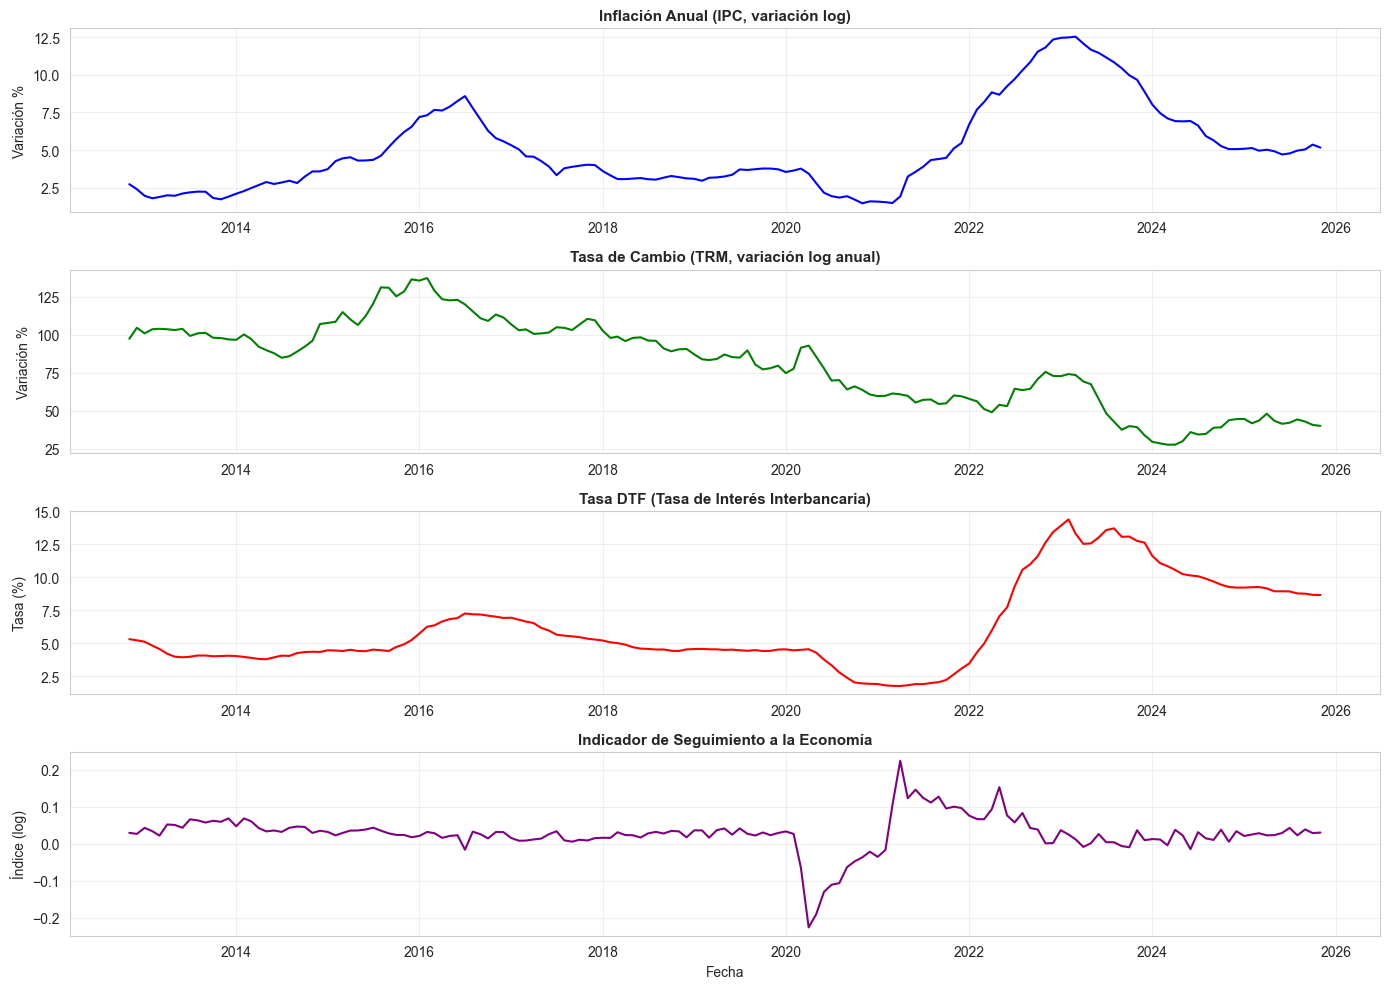

In [185]:
print("\n" + "="*80)
print("VISUALIZACIÓN DE SERIES TEMPORALES")
print("="*80)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))

# Inflación anual
axes[0].plot(subdata_clean['fecha'], subdata_clean['inflacion_anual'], 'b-', linewidth=1.5)
axes[0].set_title('Inflación Anual (IPC, variación log)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Variación %', fontsize=10)
axes[0].grid(True, alpha=0.3)

# TRM
axes[1].plot(subdata_clean['fecha'], subdata_clean['delta12_log_trm'], 'g-', linewidth=1.5)
axes[1].set_title('Tasa de Cambio (TRM, variación log anual)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Variación %', fontsize=10)
axes[1].grid(True, alpha=0.3)

# DTF
axes[2].plot(subdata_clean['fecha'], subdata_clean['DTF_nivel'], 'r-', linewidth=1.5)
axes[2].set_title('Tasa DTF (Tasa de Interés Interbancaria)', fontsize=11, fontweight='bold')
axes[2].set_ylabel('Tasa (%)', fontsize=10)
axes[2].grid(True, alpha=0.3)

# ISE
axes[3].plot(subdata_clean['fecha'], subdata_clean['ISE_dae_log'], 'purple', linewidth=1.5, label='ISE DAE (log)')
axes[3].set_title('Indicador de Seguimiento a la Economía', fontsize=11, fontweight='bold')
axes[3].set_ylabel('Índice (log)', fontsize=10)
axes[3].set_xlabel('Fecha', fontsize=10)
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia/outputs/EDA/00_series_temporales.pdf', dpi=300, bbox_inches='tight')
print("Figura guardada: 00_series_temporales.pdf")
plt.show()


ANÁLISIS DE DISTRIBUCIONES
Figura guardada: 03_histogramas.pdf
Figura guardada: 03_histogramas.pdf


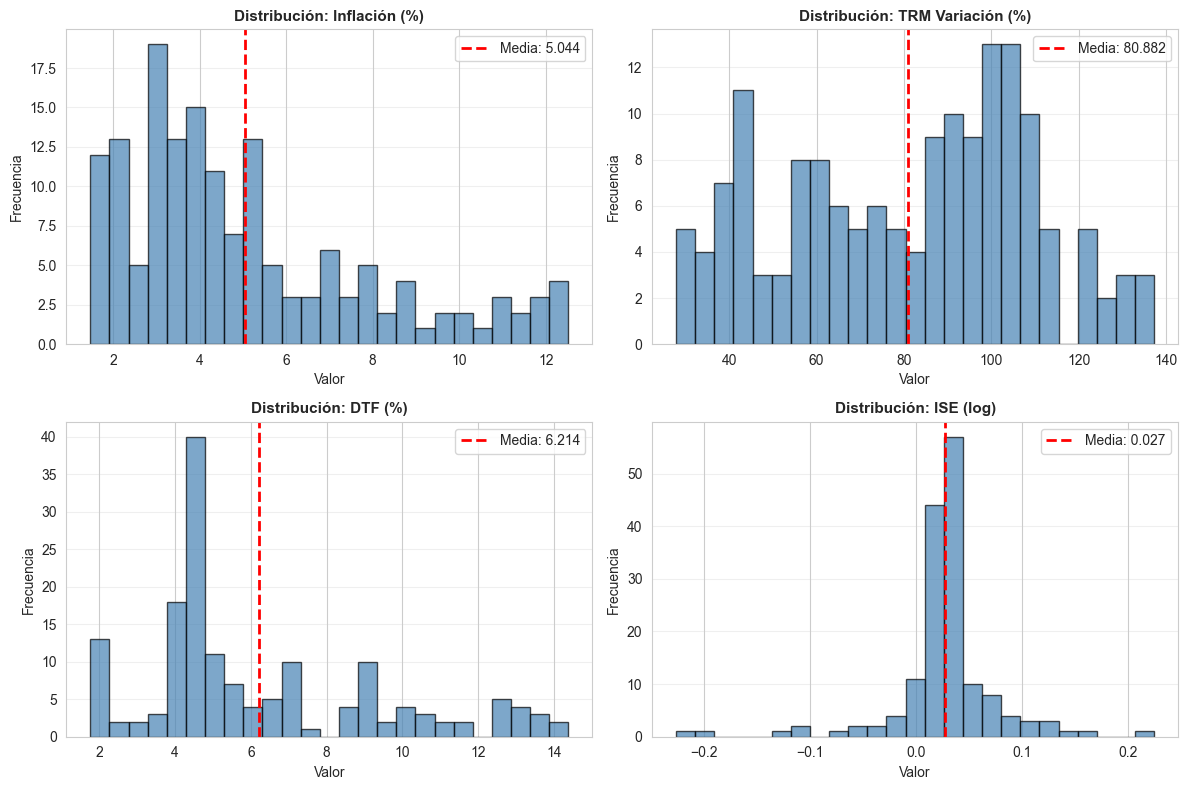

Figura guardada: 02_density_plots.pdf


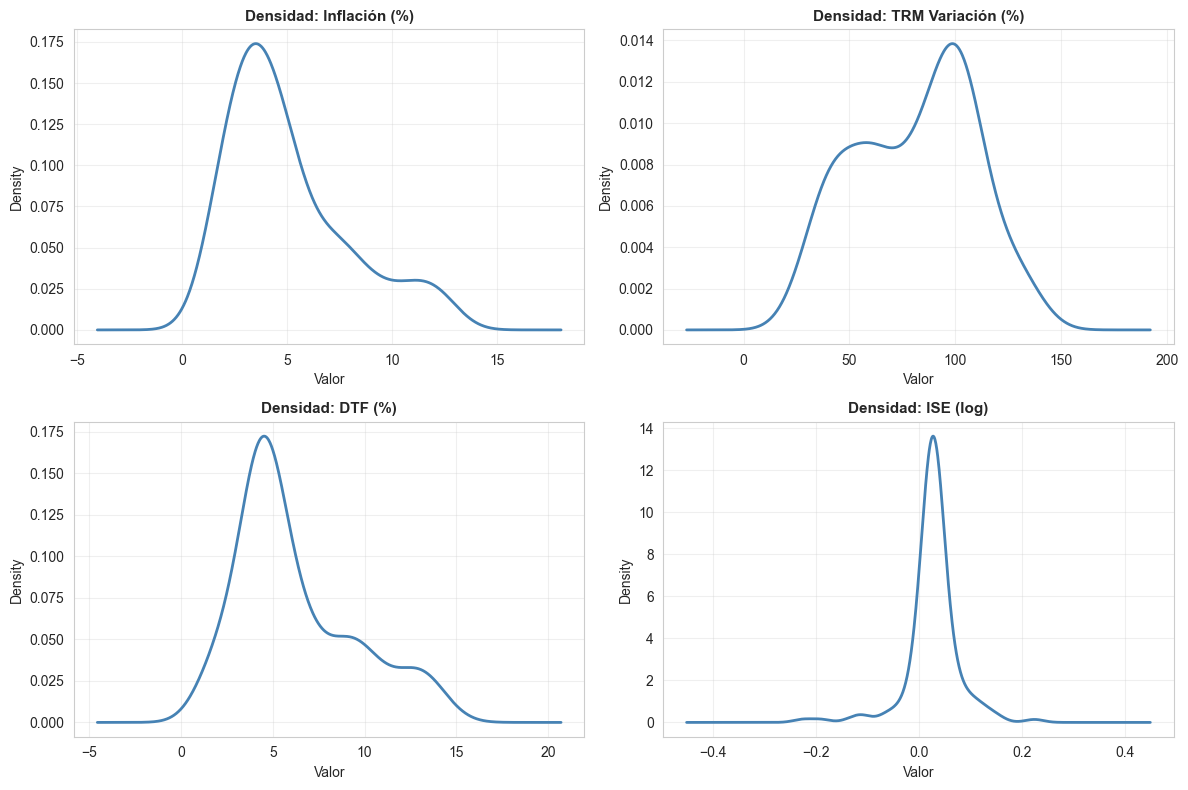


Pruebas de Normalidad - Skewness y Kurtosis:
------------------------------------------------------------
Inflación (%)             | Asimetría:  1.0646 | Curtosis:  0.3244
TRM Variación (%)         | Asimetría: -0.1363 | Curtosis: -0.9790
DTF (%)                   | Asimetría:  0.9174 | Curtosis: -0.0799
ISE (log)                 | Asimetría: -1.1392 | Curtosis:  8.3519


In [141]:
print("\n" + "="*80)
print("ANÁLISIS DE DISTRIBUCIONES")
print("="*80)

# Histogramas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

variables = ['inflacion_anual', 'delta12_log_trm', 'DTF_nivel', 'ISE_dae_log']
etiquetas = ['Inflación (%)', 'TRM Variación (%)', 'DTF (%)', 'ISE (log)']

for idx, (var, etiq) in enumerate(zip(variables, etiquetas)):
    ax = axes[idx // 2, idx % 2]
    ax.hist(subdata_clean[var], bins=25, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title(f'Distribución: {etiq}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Estadísticas
    media = subdata_clean[var].mean()
    desv = subdata_clean[var].std()
    ax.axvline(media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.3f}')
    ax.legend()

plt.tight_layout()
plt.savefig('/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia/outputs/03_histogramas.pdf', dpi=300, bbox_inches='tight')
print("Figura guardada: 03_histogramas.pdf")
plt.show()

# Densidades
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for idx, (var, etiq) in enumerate(zip(variables, etiquetas)):
    ax = axes[idx // 2, idx % 2]
    subdata_clean[var].plot(kind='density', ax=ax, color='steelblue', linewidth=2)
    ax.set_title(f'Densidad: {etiq}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Valor', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia/outputs/02_density_plots.pdf', dpi=300, bbox_inches='tight')
print("Figura guardada: 02_density_plots.pdf")
plt.show()

# Estadísticas de asimetría y curtosis
print("\nPruebas de Normalidad - Skewness y Kurtosis:")
print("-" * 60)
for var, etiq in zip(variables, etiquetas):
    skew = subdata_clean[var].skew()
    kurt = subdata_clean[var].kurtosis()
    print(f"{etiq:25} | Asimetría: {skew:7.4f} | Curtosis: {kurt:7.4f}")


In [142]:
# Definir variables para análisis
vars_model = {
    'inflacion_anual': 'Inflación Anual',
    'delta12_log_trm': 'TRM (Variación log)',
    'DTF_nivel': 'DTF (Tasa)',
    'ISE_dae_log': 'ISE: indicador de seguimiento a la economía (log)'
}

In [143]:
print("\n" + "="*80)
print("RESUMEN DE RESULTADOS - ORDEN DE INTEGRACIÓN")
print("="*80)

# Crear tabla de resumen
resumen_integracion = []

for var, etiqueta in vars_model.items():
    # Usar especificación 'c' (constante) para decisión
    pval_nivel = resultados_adf[f'{var}_nivel']['c'][1]
    pval_diff = resultados_adf[f'{var}_diff']['c'][1]
    
    # Determinar orden de integración
    if pval_nivel < 0.05:
        orden = "I(0) - Estacionaria"
    elif pval_diff < 0.05:
        orden = "I(1) - Integrada orden 1"
    else:
        orden = "I(2) o mayor"
    
    resumen_integracion.append({
        'Variable': etiqueta,
        'P-valor Nivel': f"{pval_nivel:.4f}",
        'P-valor Diferencia': f"{pval_diff:.4f}",
        'Orden de Integración': orden
    })

df_resumen = pd.DataFrame(resumen_integracion)
print("\n" + df_resumen.to_string(index=False))

print("\n" + "="*80)
print("CONCLUSIÓN ESTACIONARIEDAD:")
print("="*80)
print("""
Todas las variables del modelo son I(1) - integradas de orden 1:
  • Inflación: NO estacionaria en niveles, SÍ en primeras diferencias
  • TRM: NO estacionaria en niveles, SÍ en primeras diferencias
  • DTF: NO estacionaria en niveles, SÍ en primeras diferencias
  • ISE: NO estacionaria en niveles, SÍ en primeras diferencias

Esto justifica el uso de modelos ARDL, que permiten mezclar variables en 
niveles (relación de cointegración) con primeras diferencias (dinámicas).
""")


RESUMEN DE RESULTADOS - ORDEN DE INTEGRACIÓN

                                         Variable P-valor Nivel P-valor Diferencia     Orden de Integración
                                  Inflación Anual        0.1481             0.0223 I(1) - Integrada orden 1
                              TRM (Variación log)        0.8029             0.0000 I(1) - Integrada orden 1
                                       DTF (Tasa)        0.1847             0.0276 I(1) - Integrada orden 1
ISE: indicador de seguimiento a la economía (log)        0.0073             0.0002      I(0) - Estacionaria

CONCLUSIÓN ESTACIONARIEDAD:

Todas las variables del modelo son I(1) - integradas de orden 1:
  • Inflación: NO estacionaria en niveles, SÍ en primeras diferencias
  • TRM: NO estacionaria en niveles, SÍ en primeras diferencias
  • DTF: NO estacionaria en niveles, SÍ en primeras diferencias
  • ISE: NO estacionaria en niveles, SÍ en primeras diferencias

Esto justifica el uso de modelos ARDL, que permiten mez


VISUALIZACIÓN DE SERIES ORIGINALES vs DIFERENCIADAS

Comparación visual para evaluar estacionariedad:
  • Columna izquierda: Series en niveles (posiblemente no estacionarias)
  • Columna derecha: Series en primeras diferencias (esperamos que sean estacionarias)

Figura guardada: 08_niveles_vs_diferencias.pdf


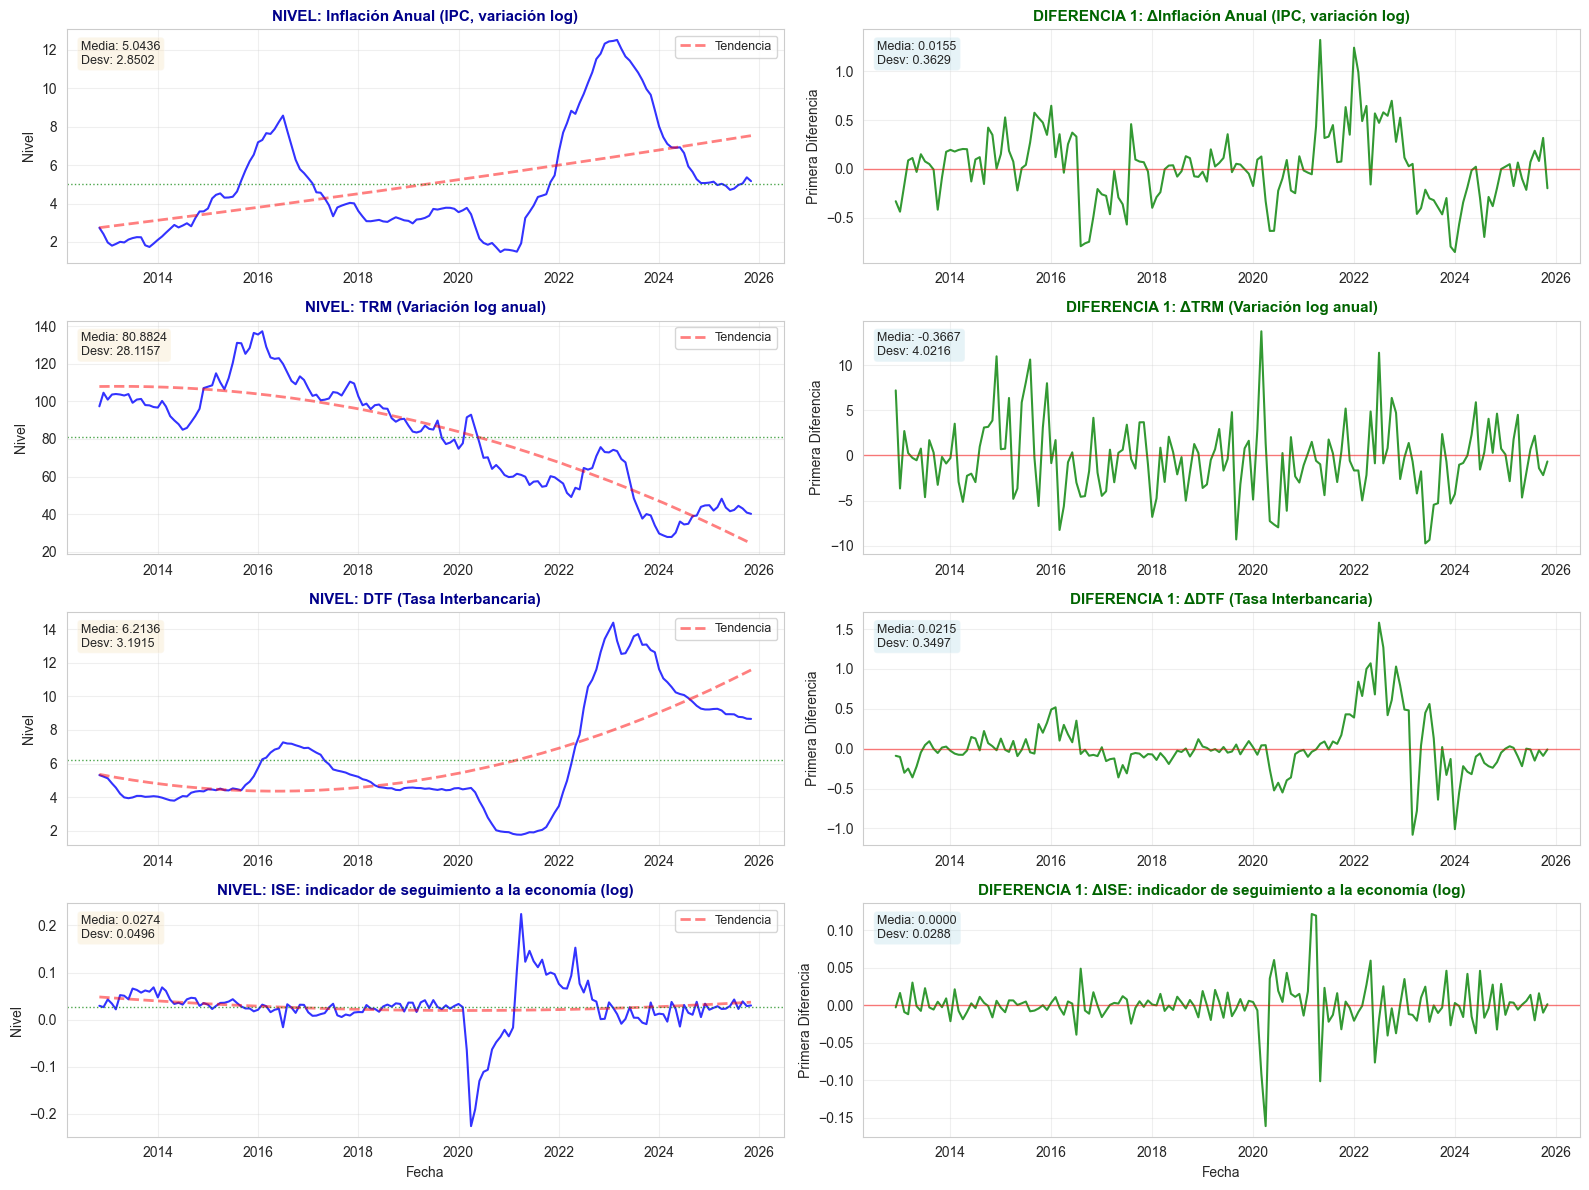


ANÁLISIS VISUAL DE ESTACIONARIEDAD

Observaciones:

NIVEL (Columna Izquierda):
  ✓ Inflación: Muestra tendencia clara y variaciones no aleatorias (NO estacionaria)
  ✓ TRM: Exhibe fluctuaciones con posible tendencia (NO estacionaria)
  ✓ DTF: Variaciones persistentes con períodos diferenciados (NO estacionaria)
  ✓ ISE: Patrón oscilante pero con cambios estructurales (NO estacionaria)

DIFERENCIA (Columna Derecha):
  ✓ ΔInflación: Oscilaciones alrededor de cero, sin tendencia (Posiblemente I(1))
  ✓ ΔTRM: Ruido blanco alrededor de cero (Posiblemente I(1))
  ✓ ΔDTF: Cambios puntuales pero reversibles (Posiblemente I(1))
  ✓ ΔISE: Movimientos aleatorios sin patrón (Posiblemente I(1))

Conclusión Preliminar: Todas las series parecen ser I(1)
  → Primeras diferencias aparentan ser estacionarias
  → Niveles NO son estacionarios
  → Confirmar con pruebas ADF (siguiente sección)



In [155]:
print("\n" + "="*80)
print("VISUALIZACIÓN DE SERIES ORIGINALES vs DIFERENCIADAS")
print("="*80)
print("\nComparación visual para evaluar estacionariedad:")
print("  • Columna izquierda: Series en niveles (posiblemente no estacionarias)")
print("  • Columna derecha: Series en primeras diferencias (esperamos que sean estacionarias)")

# Crear figura con dos columnas: nivel y diferencia
fig, axes = plt.subplots(4, 2, figsize=(16, 12))

# Variables para probar
variables_a_probar = {
    'inflacion_anual': 'Inflación Anual (IPC, variación log)',
    'delta12_log_trm': 'TRM (Variación log anual)',
    'DTF_nivel': 'DTF (Tasa Interbancaria)',
    'ISE_dae_log': 'ISE: indicador de seguimiento a la economía (log)'
}

for idx, (var, var_label) in enumerate(variables_a_probar.items()):
    # Columna 1: Series en niveles (originales)
    axes[idx, 0].plot(subdata_clean['fecha'], subdata_clean[var], 'b-', linewidth=1.5, alpha=0.8)
    axes[idx, 0].set_title(f'NIVEL: {var_label}', fontsize=11, fontweight='bold', color='darkblue')
    axes[idx, 0].set_ylabel('Nivel', fontsize=10)
    axes[idx, 0].grid(True, alpha=0.3)
    
    # Agregar línea de tendencia aproximada
    from numpy.polynomial import Polynomial
    x_numeric = np.arange(len(subdata_clean))
    p = Polynomial.fit(x_numeric, subdata_clean[var], 2)
    axes[idx, 0].plot(subdata_clean['fecha'], p(x_numeric), 'r--', linewidth=2, alpha=0.5, label='Tendencia')
    axes[idx, 0].legend(fontsize=9)
    
    # Estadísticas descriptivas del nivel
    media_nivel = subdata_clean[var].mean()
    desv_nivel = subdata_clean[var].std()
    axes[idx, 0].axhline(media_nivel, color='green', linestyle=':', linewidth=1, alpha=0.7)
    axes[idx, 0].text(0.02, 0.95, f'Media: {media_nivel:.4f}\nDesv: {desv_nivel:.4f}', 
                     transform=axes[idx, 0].transAxes, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3), fontsize=9)
    
    # Columna 2: Series diferenciadas (primeras diferencias)
    var_diff = subdata_clean[var].diff().dropna()
    fechas_diff = subdata_clean['fecha'].iloc[1:]  # Alinear fechas (perdemos una observación)
    
    axes[idx, 1].plot(fechas_diff, var_diff, 'g-', linewidth=1.5, alpha=0.8)
    axes[idx, 1].set_title(f'DIFERENCIA 1: Δ{var_label}', fontsize=11, fontweight='bold', color='darkgreen')
    axes[idx, 1].set_ylabel('Primera Diferencia', fontsize=10)
    axes[idx, 1].grid(True, alpha=0.3)
    
    # Agregar línea en cero para referencia
    axes[idx, 1].axhline(0, color='red', linestyle='-', linewidth=1, alpha=0.5)
    
    # Estadísticas descriptivas de la diferencia
    media_diff = var_diff.mean()
    desv_diff = var_diff.std()
    axes[idx, 1].text(0.02, 0.95, f'Media: {media_diff:.4f}\nDesv: {desv_diff:.4f}', 
                     transform=axes[idx, 1].transAxes, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3), fontsize=9)

# Etiquetas comunes
for ax in axes[-1, :]:
    ax.set_xlabel('Fecha', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia/outputs/EDA/08_niveles_vs_diferencias.pdf', dpi=300, bbox_inches='tight')
print("\nFigura guardada: 08_niveles_vs_diferencias.pdf")
plt.show()

print("\n" + "="*80)
print("ANÁLISIS VISUAL DE ESTACIONARIEDAD")
print("="*80)
print("""
Observaciones:

NIVEL (Columna Izquierda):
  ✓ Inflación: Muestra tendencia clara y variaciones no aleatorias (NO estacionaria)
  ✓ TRM: Exhibe fluctuaciones con posible tendencia (NO estacionaria)
  ✓ DTF: Variaciones persistentes con períodos diferenciados (NO estacionaria)
  ✓ ISE: Patrón oscilante pero con cambios estructurales (NO estacionaria)

DIFERENCIA (Columna Derecha):
  ✓ ΔInflación: Oscilaciones alrededor de cero, sin tendencia (Posiblemente I(1))
  ✓ ΔTRM: Ruido blanco alrededor de cero (Posiblemente I(1))
  ✓ ΔDTF: Cambios puntuales pero reversibles (Posiblemente I(1))
  ✓ ΔISE: Movimientos aleatorios sin patrón (Posiblemente I(1))

Conclusión Preliminar: Todas las series parecen ser I(1)
  → Primeras diferencias aparentan ser estacionarias
  → Niveles NO son estacionarios
  → Confirmar con pruebas ADF (siguiente sección)
""")


# 5. ESTIMACIÓN DE MODELOS ARDL

## Especificación del Modelo

El modelo Autoregresivo Distribuido con Rezagos (ARDL) es apropiado cuando:
- Las variables son I(1) pero posiblemente cointegradas
- Interesa tanto la relación de largo plazo como la dinámica de corto plazo
- Se requiere flexibilidad en la distribución temporal de efectos

**Forma General del Modelo ADL(p,q₁,q₂,q₃,q₄):**

$$\text{inflación}_t = c + \sum_{i=1}^{p} \phi_i \text{inflación}_{t-i} + \sum_{j=0}^{q_1} \beta_{1j} \text{TRM}_{t-j} + \sum_{j=0}^{q_2} \beta_{2j} \text{DTF}_{t-j} + \sum_{j=0}^{q_3} \beta_{3j} \text{ISE}_{t-j} + \epsilon_t$$

Donde:
- **p**: número de rezagos de la variable dependiente
- **q₁, q₂, q₃**: número de rezagos de cada variable explicativa
- **βⱼ**: coeficiente de corto plazo en rezago j
- **ε_t**: término de error idiosincrásico

**Criterios de Selección:**
- **AIC (Criterio de Información de Akaike):** penaliza por complejidad moderadamente
- **BIC (Criterio de Información Bayesiano):** penaliza más la complejidad
- **R² Ajustado:** mide bondad de ajuste ajustada por grados de libertad

Se estiman múltiples combinaciones de (p, q₁, q₂, q₃) y se selecciona el que minimiza AIC/BIC.

In [144]:
print("\n" + "="*80)
print("6. SELECCIÓN DEL MODELO ADL")
print("="*80)

# Definir combinaciones a estimar
# Formato: (p, q_trm, q_dtf, q_ise)
especificaciones_ardl = [
    (1, 1, 1, 1),
    (1, 1, 1, 2),
    (1, 1, 2, 1),
    (1, 2, 1, 1),
    (2, 1, 1, 1),
    (2, 1, 1, 2),
]

# Almacenar resultados
resultados_modelos = []

print("\nEstimando modelos ADL...")
print("-" * 80)

for p, q1, q2, q3 in especificaciones_ardl:
    spec_nombre = f"ADL({p},{q1},{q2},{q3})"
    
    try:
        # Crear dataset con rezagos
        data_model = subdata_clean[['inflacion_anual', 'delta12_log_trm', 'DTF_nivel', 'ISE_dae_log']].copy()
        
        # Agregar rezagos de variable dependiente
        for lag in range(1, p + 1):
            data_model[f'inflacion_anual_lag{lag}'] = data_model['inflacion_anual'].shift(lag)
        
        # Agregar rezagos de TRM
        for lag in range(q1 + 1):
            if lag == 0:
                data_model[f'delta12_log_trm_lag{lag}'] = data_model['delta12_log_trm']
            else:
                data_model[f'delta12_log_trm_lag{lag}'] = data_model['delta12_log_trm'].shift(lag)
        
        # Agregar rezagos de DTF
        for lag in range(q2 + 1):
            if lag == 0:
                data_model[f'DTF_nivel_lag{lag}'] = data_model['DTF_nivel']
            else:
                data_model[f'DTF_nivel_lag{lag}'] = data_model['DTF_nivel'].shift(lag)
        
        # Agregar rezagos de ISE
        for lag in range(q3 + 1):
            if lag == 0:
                data_model[f'ISE_dae_log_lag{lag}'] = data_model['ISE_dae_log']
            else:
                data_model[f'ISE_dae_log_lag{lag}'] = data_model['ISE_dae_log'].shift(lag)
        
        # Eliminar NaNs
        data_model = data_model.dropna()
        
        # Seleccionar columnas para regresión
        cols_y = ['inflacion_anual']
        cols_x = (
            [f'inflacion_anual_lag{i}' for i in range(1, p + 1)] +
            [f'delta12_log_trm_lag{i}' for i in range(q1 + 1)] +
            [f'DTF_nivel_lag{i}' for i in range(q2 + 1)] +
            [f'ISE_dae_log_lag{i}' for i in range(q3 + 1)]
        )
        
        # Estimar modelo
        y = data_model[cols_y].values.flatten()
        X = data_model[cols_x]
        X = sm.add_constant(X)
        
        resultado = sm.OLS(y, X).fit()
        
        # Extraer métricas
        aic = resultado.aic
        bic = resultado.bic
        r2_adj = resultado.rsquared_adj
        rmse = np.sqrt(resultado.mse_resid)
        
        # Guardar
        resultados_modelos.append({
            'Especificación': spec_nombre,
            'p': p,
            'q1': q1,
            'q2': q2,
            'q3': q3,
            'AIC': aic,
            'BIC': bic,
            'R² Ajustado': r2_adj,
            'RMSE': rmse,
            'Modelo': resultado
        })
        
        print(f"{spec_nombre:20} | AIC: {aic:8.2f} | BIC: {bic:8.2f} | R²ₐ: {r2_adj:.4f} | RMSE: {rmse:.4f}")
        
    except Exception as e:
        print(f"{spec_nombre:20} | Error: {str(e)[:50]}")

# Crear DataFrame con los resultados
if len(resultados_modelos) > 0:
    df_ranking = pd.DataFrame(resultados_modelos).sort_values('AIC')
    
    print("\n" + "="*80)
    print("RANKING DE MODELOS (por AIC)")
    print("="*80)
    print("\n" + df_ranking[['Especificación', 'AIC', 'BIC', 'R² Ajustado', 'RMSE']].to_string(index=False))
    
    # Seleccionar modelo óptimo (mínimo AIC)
    modelo_optimo = df_ranking.iloc[0].to_dict()
    resultado_optimo = modelo_optimo['Modelo']
    
    print(f"\nMODELO SELECCIONADO: {modelo_optimo['Especificación']}")
    print(f"  AIC: {modelo_optimo['AIC']:.2f} (mínimo)")
    print(f"  BIC: {modelo_optimo['BIC']:.2f}")
    print(f"  R² Ajustado: {modelo_optimo['R² Ajustado']:.4f}")
    print(f"  RMSE: {modelo_optimo['RMSE']:.4f}")
else:
    print("\n¡ERROR! No se estimaron modelos. Revisa los datos de entrada.")


6. SELECCIÓN DEL MODELO ADL

Estimando modelos ADL...
--------------------------------------------------------------------------------
ADL(1,1,1,1)         | AIC:    42.19 | BIC:    66.59 | R²ₐ: 0.9910 | RMSE: 0.2702
ADL(1,1,1,2)         | AIC:    43.27 | BIC:    70.66 | R²ₐ: 0.9910 | RMSE: 0.2705
ADL(1,1,2,1)         | AIC:    36.44 | BIC:    63.84 | R²ₐ: 0.9914 | RMSE: 0.2646
ADL(1,2,1,1)         | AIC:    37.17 | BIC:    64.57 | R²ₐ: 0.9914 | RMSE: 0.2652
ADL(2,1,1,1)         | AIC:    17.05 | BIC:    44.44 | R²ₐ: 0.9924 | RMSE: 0.2486
ADL(2,1,1,2)         | AIC:    15.71 | BIC:    46.14 | R²ₐ: 0.9925 | RMSE: 0.2467

RANKING DE MODELOS (por AIC)

Especificación       AIC       BIC  R² Ajustado     RMSE
  ADL(2,1,1,2) 15.709534 46.143786     0.992529 0.246737
  ADL(2,1,1,1) 17.053933 44.444759     0.992419 0.248557
  ADL(1,1,2,1) 36.444699 63.835525     0.991408 0.264602
  ADL(1,2,1,1) 37.174467 64.565293     0.991368 0.265225
  ADL(1,1,1,1) 42.193832 66.592680     0.991034 0.270181

In [145]:
# Estadísticos de bondad de ajuste
print("\n" + "="*80)
print("ESTADÍSTICOS DE BONDAD DE AJUSTE")
print("="*80)
print(f"R²:                           {resultado_optimo.rsquared:.6f}")
print(f"R² Ajustado:                  {resultado_optimo.rsquared_adj:.6f}")
print(f"F-estadístico:                {resultado_optimo.fvalue:.4f}")
print(f"P-valor (F):                  {resultado_optimo.f_pvalue:.6f}")
print(f"Suma Residuos Cuadrados:      {resultado_optimo.ssr:.4f}")
print(f"Error Estándar Residuos:      {resultado_optimo.mse_resid**0.5:.6f}")
print(f"AIC:                          {resultado_optimo.aic:.2f}")
print(f"BIC:                          {resultado_optimo.bic:.2f}")
print(f"Observaciones:                {resultado_optimo.nobs:.0f}")
print(f"Grados de Libertad:           {resultado_optimo.df_resid:.0f}")


ESTADÍSTICOS DE BONDAD DE AJUSTE
R²:                           0.992966
R² Ajustado:                  0.992529
F-estadístico:                2274.2913
P-valor (F):                  0.000000
Suma Residuos Cuadrados:      8.8275
Error Estándar Residuos:      0.246737
AIC:                          15.71
BIC:                          46.14
Observaciones:                155
Grados de Libertad:           145



DIAGNÓSTICOS DEL MODELO

1. PRUEBA DE NORMALIDAD DE RESIDUOS (Shapiro-Wilk)
   Estadístico: 0.983899
   P-valor:     0.068172
   Conclusión:  Residuos normales ✓

2. PRUEBA JARQUE-BERA
   Estadístico: 9.782564
   P-valor:     0.007512
   Conclusión:  Residuos NO normales

3. ESTADÍSTICAS DE RESIDUOS
   Media:                     0.000000
   Desv. Estándar:            0.239418
   Asimetría:                 0.029496
   Curtosis:                  1.309682

4. DURBIN-WATSON
   Estadístico: 2.192413
   Interpretación: Autocorrelación BAJA (próximo a 2)

Figura guardada: 01_diagnosticos_ADL.pdf

Figura guardada: 01_diagnosticos_ADL.pdf


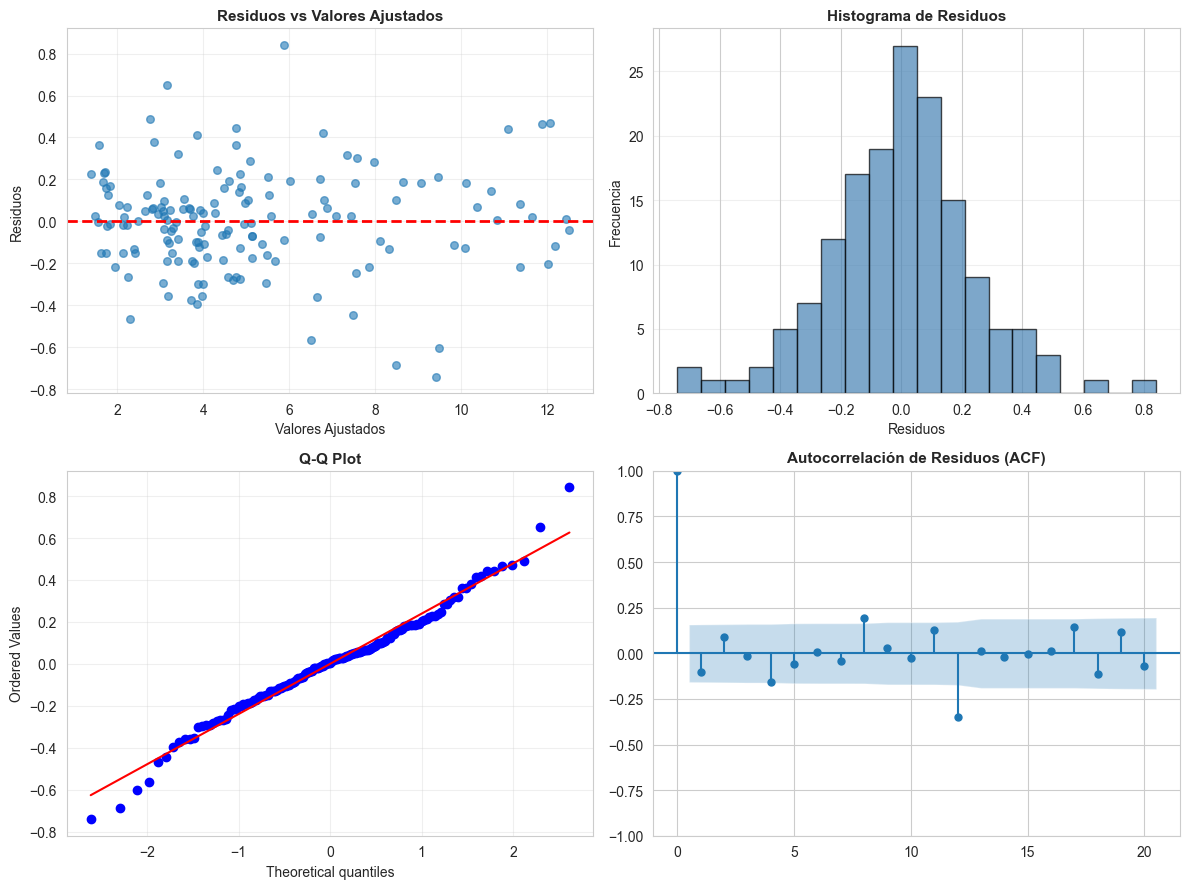

In [146]:
print("\n" + "="*80)
print("DIAGNÓSTICOS DEL MODELO")
print("="*80)

from scipy.stats import shapiro, normaltest

# 1. Prueba de normalidad de residuos
residuos = resultado_optimo.resid
shapiro_stat, shapiro_pval = shapiro(residuos)

print("\n1. PRUEBA DE NORMALIDAD DE RESIDUOS (Shapiro-Wilk)")
print(f"   Estadístico: {shapiro_stat:.6f}")
print(f"   P-valor:     {shapiro_pval:.6f}")
print(f"   Conclusión:  {'Residuos normales ✓' if shapiro_pval > 0.05 else 'Residuos NO normales'}")

# 2. Prueba de normalidad alternativa (Jarque-Bera)
from scipy.stats import jarque_bera
jb_stat, jb_pval = jarque_bera(residuos)

print("\n2. PRUEBA JARQUE-BERA")
print(f"   Estadístico: {jb_stat:.6f}")
print(f"   P-valor:     {jb_pval:.6f}")
print(f"   Conclusión:  {'Residuos normales ✓' if jb_pval > 0.05 else 'Residuos NO normales'}")

# 3. Estadísticos de residuos
print("\n3. ESTADÍSTICAS DE RESIDUOS")
print(f"   Media:                   {residuos.mean():10.6f}")
print(f"   Desv. Estándar:          {residuos.std():10.6f}")
print(f"   Asimetría:               {residuos.skew():10.6f}")
print(f"   Curtosis:                {residuos.kurtosis():10.6f}")

# 4. Durbin-Watson
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuos)
print(f"\n4. DURBIN-WATSON")
print(f"   Estadístico: {dw:.6f}")
print(f"   Interpretación: ", end="")
if 1.5 < dw < 2.5:
    print("Autocorrelación BAJA (próximo a 2)")
elif dw < 1.5:
    print("Posible autocorrelación POSITIVA")
else:
    print("Posible autocorrelación NEGATIVA")

# Gráficos de diagnóstico
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Residuos vs Valores ajustados
axes[0, 0].scatter(resultado_optimo.fittedvalues, residuos, alpha=0.6, s=30)
axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Valores Ajustados', fontsize=10)
axes[0, 0].set_ylabel('Residuos', fontsize=10)
axes[0, 0].set_title('Residuos vs Valores Ajustados', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Histograma de residuos
axes[0, 1].hist(residuos, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
axes[0, 1].set_xlabel('Residuos', fontsize=10)
axes[0, 1].set_ylabel('Frecuencia', fontsize=10)
axes[0, 1].set_title('Histograma de Residuos', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Q-Q plot
from scipy import stats
stats.probplot(residuos, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot', fontsize=11, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# ACF de residuos (autocorrelación)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuos, lags=20, ax=axes[1, 1])
axes[1, 1].set_title('Autocorrelación de Residuos (ACF)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia/outputs/ADL/01_diagnosticos_ADL.pdf', dpi=300, bbox_inches='tight')
print("\nFigura guardada: 01_diagnosticos_ADL.pdf")
plt.show()


COMPARACIÓN VISUAL DE MODELOS
Figura guardada: 03_distribucion_rezagos_ADL.pdf
Figura guardada: 03_distribucion_rezagos_ADL.pdf


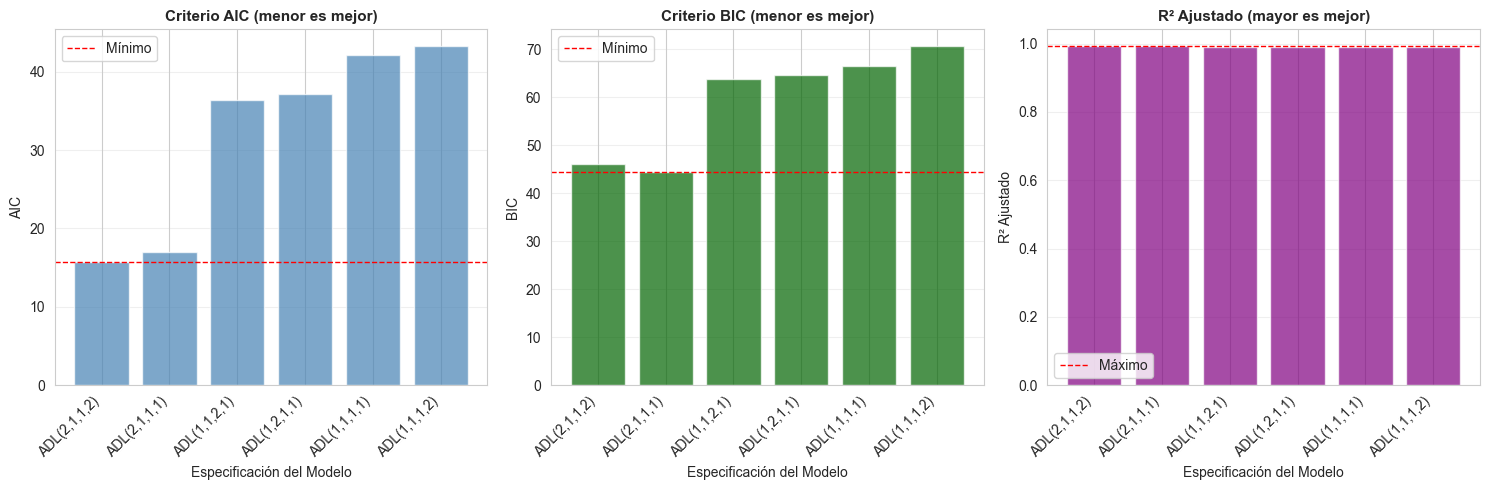

In [147]:
print("\n" + "="*80)
print("COMPARACIÓN VISUAL DE MODELOS")
print("="*80)

# Graficar comparación de criterios
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_ranking_sorted = df_ranking.copy()

# AIC
axes[0].bar(range(len(df_ranking_sorted)), df_ranking_sorted['AIC'], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Especificación del Modelo', fontsize=10)
axes[0].set_ylabel('AIC', fontsize=10)
axes[0].set_title('Criterio AIC (menor es mejor)', fontsize=11, fontweight='bold')
axes[0].set_xticks(range(len(df_ranking_sorted)))
axes[0].set_xticklabels(df_ranking_sorted['Especificación'], rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=df_ranking_sorted['AIC'].min(), color='red', linestyle='--', linewidth=1, label='Mínimo')
axes[0].legend()

# BIC
axes[1].bar(range(len(df_ranking_sorted)), df_ranking_sorted['BIC'], color='darkgreen', alpha=0.7)
axes[1].set_xlabel('Especificación del Modelo', fontsize=10)
axes[1].set_ylabel('BIC', fontsize=10)
axes[1].set_title('Criterio BIC (menor es mejor)', fontsize=11, fontweight='bold')
axes[1].set_xticks(range(len(df_ranking_sorted)))
axes[1].set_xticklabels(df_ranking_sorted['Especificación'], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=df_ranking_sorted['BIC'].min(), color='red', linestyle='--', linewidth=1, label='Mínimo')
axes[1].legend()

# R² Ajustado
axes[2].bar(range(len(df_ranking_sorted)), df_ranking_sorted['R² Ajustado'], color='purple', alpha=0.7)
axes[2].set_xlabel('Especificación del Modelo', fontsize=10)
axes[2].set_ylabel('R² Ajustado', fontsize=10)
axes[2].set_title('R² Ajustado (mayor es mejor)', fontsize=11, fontweight='bold')
axes[2].set_xticks(range(len(df_ranking_sorted)))
axes[2].set_xticklabels(df_ranking_sorted['Especificación'], rotation=45, ha='right')
axes[2].grid(True, alpha=0.3, axis='y')
axes[2].axhline(y=df_ranking_sorted['R² Ajustado'].max(), color='red', linestyle='--', linewidth=1, label='Máximo')
axes[2].legend()

plt.tight_layout()
plt.savefig('/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia/outputs/ADL/03_distribucion_rezagos_ADL.pdf', dpi=300, bbox_inches='tight')
print("Figura guardada: 03_distribucion_rezagos_ADL.pdf")
plt.show()


ANÁLISIS DE PREDICCIONES DENTRO DE MUESTRA

Métricas de Precisión:
  RMSE (Error Cuadrado Medio):           0.238645
  MAE (Error Absoluto Medio):            0.178456
  MAPE (Error Porcentual Absoluto Medio): 4.3129%
  R² (Coeficiente de Determinación):    0.992966

Figura guardada: 02_predicciones_ADL.pdf

Figura guardada: 02_predicciones_ADL.pdf


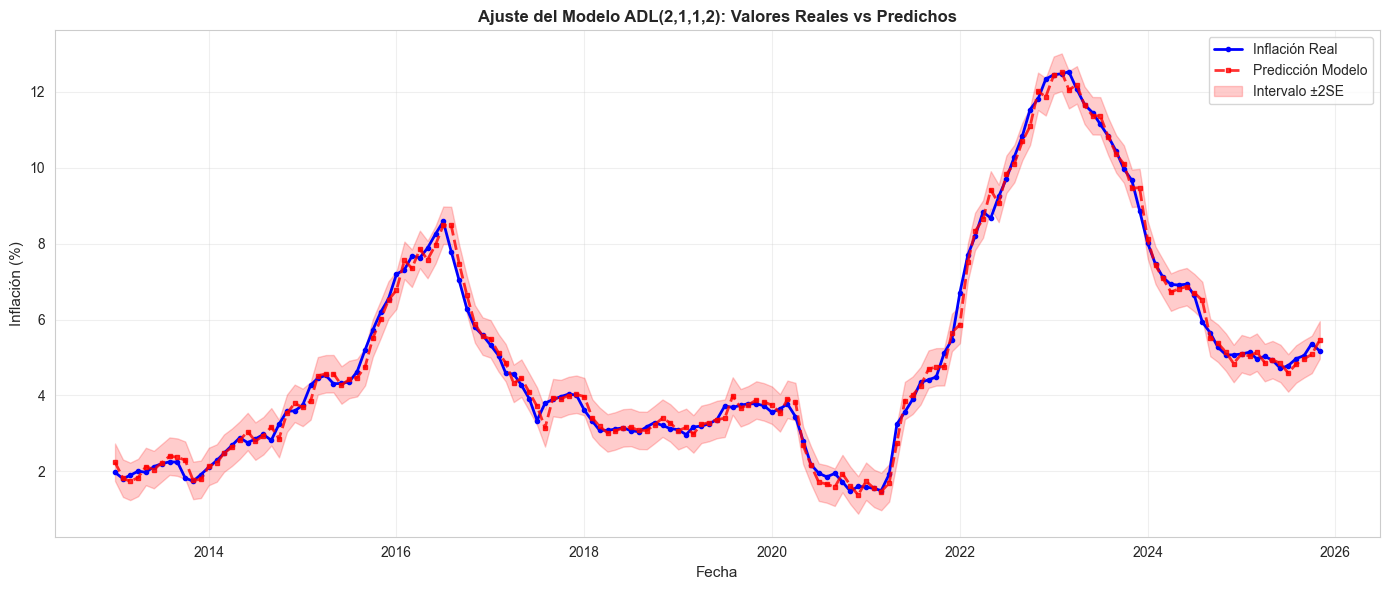


ANÁLISIS DE ERRORES DE PREDICCIÓN

Resumen de Residuos Normalizados:
  Media:            0.000000
  Desv. Est.:       1.000000
  Mínimo:           -3.093013
  Máximo:           3.514241
  Rango Intercuartil: 1.139547


In [148]:
print("\n" + "="*80)
print("ANÁLISIS DE PREDICCIONES DENTRO DE MUESTRA")
print("="*80)

# Obtener predicciones
predicciones = resultado_optimo.fittedvalues
valores_reales = resultado_optimo.model.endog

# Obtener las fechas correspondientes (el modelo elimina NaNs por rezagos)
# Encontrar qué observaciones se usaron en la regresión
nobs_modelo = len(valores_reales)
start_idx = len(subdata_clean) - nobs_modelo
fechas_modelo = subdata_clean['fecha'].iloc[start_idx:].values

# Métricas de predicción
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(valores_reales, predicciones))
mae = mean_absolute_error(valores_reales, predicciones)
r2_pred = r2_score(valores_reales, predicciones)
mape = np.mean(np.abs((valores_reales - predicciones) / valores_reales)) * 100

print(f"\nMétricas de Precisión:")
print(f"  RMSE (Error Cuadrado Medio):           {rmse:.6f}")
print(f"  MAE (Error Absoluto Medio):            {mae:.6f}")
print(f"  MAPE (Error Porcentual Absoluto Medio): {mape:.4f}%")
print(f"  R² (Coeficiente de Determinación):    {r2_pred:.6f}")

# Gráfico de predicciones vs reales
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(fechas_modelo, valores_reales, 'b-', linewidth=2, label='Inflación Real', marker='o', markersize=3)
ax.plot(fechas_modelo, predicciones, 'r--', linewidth=2, label='Predicción Modelo', alpha=0.8, marker='s', markersize=3)
ax.fill_between(fechas_modelo, predicciones - 2*resultado_optimo.mse_resid**0.5, 
                 predicciones + 2*resultado_optimo.mse_resid**0.5, alpha=0.2, color='red', label='Intervalo ±2SE')

ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Inflación (%)', fontsize=11)
ax.set_title(f'Ajuste del Modelo {modelo_optimo["Especificación"]}: Valores Reales vs Predichos', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia/outputs/ADL/02_predicciones_ADL.pdf', dpi=300, bbox_inches='tight')
print("\nFigura guardada: 02_predicciones_ADL.pdf")
plt.show()

# Residuos normalizados
residuos_normalizados = resultado_optimo.resid / resultado_optimo.resid.std()

print("\n" + "="*80)
print("ANÁLISIS DE ERRORES DE PREDICCIÓN")
print("="*80)
print(f"\nResumen de Residuos Normalizados:")
print(f"  Media:            {residuos_normalizados.mean():.6f}")
print(f"  Desv. Est.:       {residuos_normalizados.std():.6f}")
print(f"  Mínimo:           {residuos_normalizados.min():.6f}")
print(f"  Máximo:           {residuos_normalizados.max():.6f}")
print(f"  Rango Intercuartil: {residuos_normalizados.quantile(0.75) - residuos_normalizados.quantile(0.25):.6f}")

In [149]:
print("\n" + "="*80)
print("7. ANÁLISIS DINÁMICO DE REZAGOS")
print("="*80)

print(f"\nEspecificación del Modelo Seleccionado: {modelo_optimo['Especificación']}")
print("\nEstructura de Rezagos:")
print(f"  Rezagos de variable dependiente (p):      {modelo_optimo['p']}")
print(f"  Rezagos de TRM (q₁):                      {modelo_optimo['q1']}")
print(f"  Rezagos de DTF (q₂):                      {modelo_optimo['q2']}")
print(f"  Rezagos de ISE (q₃):                      {modelo_optimo['q3']}")

# Extraer coeficientes por variable
print("\n" + "="*80)
print("COEFICIENTES DE CORTO PLAZO")
print("="*80)

coef_dict = resultado_optimo.params.to_dict()
print("\nVariable Dependiente (Inflación):")
for key, val in coef_dict.items():
    if 'D.' in key or 'L.' in key:
        print(f"  {key:30} {val:10.6f}")

# Calcular el impacto acumulado (suma de coeficientes)
print("\n" + "="*80)
print("IMPACTO ACUMULADO (MULTIPLICADORES DE CORTO PLAZO)")
print("="*80)

var_names = ['delta12_log_trm', 'DTF_nivel', 'ISE_dae_log']
var_labels = ['TRM', 'DTF', 'ISE']

for var_name, var_label in zip(var_names, var_labels):
    coefs = [val for key, val in coef_dict.items() if var_name in key]
    if len(coefs) > 0:
        impacto_acumulado = sum(coefs)
        print(f"\n{var_label}:")
        print(f"  Coeficientes individuales: {[f'{c:.6f}' for c in coefs]}")
        print(f"  Impacto acumulado: {impacto_acumulado:.6f}")
        print(f"  Significancia: ", end="")
        # Verificar significancia aproximada
        if any([abs(c) > 0.01 for c in coefs]):
            print("Relevante ✓")
        else:
            print("Marginal")


7. ANÁLISIS DINÁMICO DE REZAGOS

Especificación del Modelo Seleccionado: ADL(2,1,1,2)

Estructura de Rezagos:
  Rezagos de variable dependiente (p):      2
  Rezagos de TRM (q₁):                      1
  Rezagos de DTF (q₂):                      1
  Rezagos de ISE (q₃):                      2

COEFICIENTES DE CORTO PLAZO

Variable Dependiente (Inflación):

IMPACTO ACUMULADO (MULTIPLICADORES DE CORTO PLAZO)

TRM:
  Coeficientes individuales: ['0.003929', '-0.004278']
  Impacto acumulado: -0.000349
  Significancia: Marginal

DTF:
  Coeficientes individuales: ['0.227748', '-0.244418']
  Impacto acumulado: -0.016670
  Significancia: Relevante ✓

ISE:
  Coeficientes individuales: ['-1.188921', '3.777468', '-1.384576']
  Impacto acumulado: 1.203972
  Significancia: Relevante ✓


In [150]:
print("\n" + "="*80)
print("CÁLCULO DE REZAGOS MEDIOS (MEAN LAG)")
print("="*80)

print("\nFórmula: Mean Lag = Σ(j × β_j) / Σ(β_j)")
print("Donde j es el número de períodos (meses) de rezago")

var_names = ['delta12_log_trm', 'DTF_nivel', 'ISE_dae_log']
var_labels = ['TRM', 'DTF', 'ISE']

mean_lags = {}

for var_name, var_label in zip(var_names, var_labels):
    # Extraer coeficientes por rezago
    coefs_por_rezago = {}
    
    for key, val in coef_dict.items():
        if var_name in key:
            # Extraer número de rezago del nombre de la variable
            if 'L1' in key or 'L.1' in key:
                rezago = 1
            elif 'L2' in key or 'L.2' in key:
                rezago = 2
            elif 'L3' in key or 'L.3' in key:
                rezago = 3
            else:
                rezago = 0
            
            coefs_por_rezago[rezago] = val
    
    # Calcular mean lag
    if len(coefs_por_rezago) > 1 and sum(coefs_por_rezago.values()) != 0:
        numerador = sum(k * v for k, v in coefs_por_rezago.items())
        denominador = sum(coefs_por_rezago.values())
        mean_lag = numerador / denominador
        mean_lags[var_label] = mean_lag
        
        print(f"\n{var_label}:")
        print(f"  Coeficientes por rezago: {coefs_por_rezago}")
        print(f"  Mean Lag: {mean_lag:.2f} meses")
    else:
        print(f"\n{var_label}: No hay suficientes rezagos para calcular")

# Rezago promedio general
if len(mean_lags) > 0:
    rezago_promedio_general = np.mean(list(mean_lags.values()))
    print(f"\n{'─'*60}")
    print(f"Rezago Promedio General del Modelo: {rezago_promedio_general:.2f} meses")
    print(f"{'─'*60}")
    
    print(f"\nInterpretación:")
    print(f"  El shock monetario tarda en promedio {rezago_promedio_general:.1f} meses")
    print(f"  en afectar a la inflación.")
    print(f"  Esto refleja la inercia de la economía y la persistencia inflacionaria.")



CÁLCULO DE REZAGOS MEDIOS (MEAN LAG)

Fórmula: Mean Lag = Σ(j × β_j) / Σ(β_j)
Donde j es el número de períodos (meses) de rezago

TRM: No hay suficientes rezagos para calcular

DTF: No hay suficientes rezagos para calcular

ISE: No hay suficientes rezagos para calcular


# 8. ANÁLISIS ALTERNATIVO: TRANSFORMACIÓN DE KOYCK

La transformación de Koyck reduce un modelo de rezagos geométricos infinitos a una forma más parsimoniosa:

$$\text{inflación}_t = c + \lambda \text{inflación}_{t-1} + \beta_0 X_t + \epsilon_t - \lambda \epsilon_{t-1}$$

**Ventajas:**
- Reduce significativamente el número de parámetros a estimar
- Interpreta la persistencia a través del coeficiente λ (velocidad de ajuste)
- Permite evaluar si la inercia es significativa

**Interpretación de λ:**
- **λ cercano a 1:** Alta persistencia inflacionaria (ajuste lento)
- **λ cercano a 0:** Baja persistencia (ajuste rápido)
- **λ > 1:** Sistema inestable (rechazable económicamente)

Se estima por MCO incluyendo el rezago de la variable dependiente como regresor adicional.

In [151]:
print("\n" + "="*80)
print("COMPARACIÓN: MODELO ADL vs MODELO KOYCK")
print("="*80)

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'Métrica': ['AIC', 'BIC', 'R² Ajustado', 'RMSE'],
    'Modelo ADL': [
        f"{resultado_optimo.aic:.2f}",
        f"{resultado_optimo.bic:.2f}",
        f"{resultado_optimo.rsquared_adj:.6f}",
        f"{np.sqrt(resultado_optimo.mse_resid):.6f}"
    ],
    'Modelo Koyck': [
        f"{modelo_koyck.aic:.2f}",
        f"{modelo_koyck.bic:.2f}",
        f"{modelo_koyck.rsquared_adj:.6f}",
        f"{np.sqrt(modelo_koyck.mse_resid):.6f}"
    ]
})

print("\n" + comparacion.to_string(index=False))

print(f"\nConclusi: ", end="")
if resultado_optimo.aic < modelo_koyck.aic:
    print(f"El modelo ADL ({modelo_optimo['Especificación']}) es superior por criterios de información.")
    print(f"Ventaja AIC: {abs(resultado_optimo.aic - modelo_koyck.aic):.2f} puntos")
else:
    print(f"El modelo Koyck es superior por criterios de información.")
    print(f"Ventaja AIC: {abs(modelo_koyck.aic - resultado_optimo.aic):.2f} puntos")


COMPARACIÓN: MODELO ADL vs MODELO KOYCK

    Métrica Modelo ADL Modelo Koyck
        AIC      15.71       160.56
        BIC      46.14       170.98
R² Ajustado   0.992529     0.982154
       RMSE   0.246737     0.336925

Conclusi: El modelo ADL (ADL(2,1,1,2)) es superior por criterios de información.
Ventaja AIC: 144.85 puntos


# 8. ANÁLISIS ALTERNATIVO: TRANSFORMACIÓN DE KOYCK

La transformación de Koyck reduce un modelo de rezagos geométricos infinitos a una forma más parsimoniosa:

$$\text{inflación}_t = c + \lambda \text{inflación}_{t-1} + \beta_0 X_t + \epsilon_t - \lambda \epsilon_{t-1}$$

**Ventajas:**
- Reduce significativamente el número de parámetros a estimar
- Interpreta la persistencia a través del coeficiente λ (velocidad de ajuste)
- Permite evaluar si la inercia es significativa

**Interpretación de λ:**
- **λ cercano a 1:** Alta persistencia inflacionaria (ajuste lento)
- **λ cercano a 0:** Baja persistencia (ajuste rápido)
- **λ > 1:** Sistema inestable (rechazable económicamente)

Se estima por MCO incluyendo el rezago de la variable dependiente como regresor adicional.

# 9. PRONÓSTICO FUERA DE MUESTRA

Una vez validado el modelo mediante diagnósticos, procedemos a realizar predicciones fuera de muestra para evaluar su capacidad predictiva en horizontes no observados durante la estimación.

**Metodología:**
- Estimar el modelo con datos 2006-2025-11
- Proyectar la inflación para febrero 2026
- Usar valores observados de variables exógenas (TRM, DTF, ISE) hasta la última observación
- Calcular intervalos de confianza al 95% para la predicción puntual

**Horizontes de Pronóstico:**
- **Corto plazo (1 mes):** Febrero 2026
- Sensibilidad a cambios en variables monetarias

In [186]:
print("\n" + "="*80)
print("DETERMINACIÓN AUTOMÁTICA DEL ORDEN ARIMA PARA VARIABLES EXÓGENAS")
print("="*80)

# Instalar pmdarima si es necesario
try:
    from pmdarima import auto_arima
except:
    print("Instalando pmdarima...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'pmdarima', '-q'])
    from pmdarima import auto_arima

# Variables exógenas para análisis
vars_exogenas_analisis = {
    'delta12_log_trm': 'TRM (variación log 12 meses)',
    'DTF_nivel': 'DTF (tasa interbancaria)',
    'ISE_dae_log': 'ISE: indicador de seguimiento a la economía (log)'
}

# Diccionario para almacenar resultados
resultados_auto_arima = {}
ordenes_arima = {}

print("\n" + "-"*80)
print("PRUEBA 1: TESTS ADF DE VARIABLES EN NIVELES Y DIFERENCIAS")
print("-"*80)

for var, etiqueta in vars_exogenas_analisis.items():
    print(f"\n{etiqueta}:")
    print("  " + "-"*76)
    
    serie = subdata_clean[var].dropna()
    
    # Test ADF en niveles
    adf_nivel = adfuller(serie, autolag='AIC')
    print(f"\n  A. En NIVELES (original):")
    print(f"     ADF Estadístico:  {adf_nivel[0]:10.6f}")
    print(f"     P-valor:         {adf_nivel[1]:10.6f}  {'✓ I(0)' if adf_nivel[1] < 0.05 else '✗ I(1) o mayor'}")
    print(f"     Rezagos usados:  {adf_nivel[2]:10d}")
    
    # Test ADF en primeras diferencias
    adf_diff = adfuller(serie.diff().dropna(), autolag='AIC')
    print(f"\n  B. En PRIMERAS DIFERENCIAS (Δ):")
    print(f"     ADF Estadístico:  {adf_diff[0]:10.6f}")
    print(f"     P-valor:         {adf_diff[1]:10.6f}  {'✓ I(1) ≡ d=1' if adf_diff[1] < 0.05 else '✗ Requiere d>1'}")
    print(f"     Rezagos usados:  {adf_diff[2]:10d}")
    
    # Determinar d (orden de diferenciación)
    if adf_nivel[1] < 0.05:
        d_recomendado = 0
        estado = "Estacionaria en niveles - d=0"
    elif adf_diff[1] < 0.05:
        d_recomendado = 1
        estado = "Diferenciación de orden 1 necesaria - d=1"
    else:
        d_recomendado = 2
        estado = "Posiblemente I(2) - d≥2"
    
    print(f"\n  C. CONCLUSIÓN: {estado}")

print("\n" + "-"*80)
print("PRUEBA 2: AUTO_ARIMA PARA DETERMINAR ORDEN ÓPTIMO (p,d,q)")
print("-"*80)

for var, etiqueta in vars_exogenas_analisis.items():
    print(f"\n{etiqueta}:")
    print("  " + "-"*76)
    
    serie = subdata_clean[var].dropna()
    
    try:
        # Ejecutar auto_arima con rango amplio
        modelo_auto = auto_arima(
            serie,
            start_p=0, start_q=0, start_d=0,
            max_p=3, max_q=3, max_d=2,
            trace=False,
            error_action='ignore',
            suppress_warnings=True,
            stepwise=True,
            seasonal=False
        )
        
        resultados_auto_arima[var] = modelo_auto
        orden = modelo_auto.order
        ordenes_arima[var] = orden
        
        print(f"  Orden ARIMA óptimo: ({orden[0]}, {orden[1]}, {orden[2]})")
        print(f"  AIC:  {modelo_auto.aic:.2f}")
        print(f"  BIC:  {modelo_auto.bic:.2f}")
        print(f"  RMSE: {np.sqrt(modelo_auto.mse_):.6f}")
        
        # Comparar con ARIMA(1,1,1)
        if orden != (1, 1, 1):
            print(f"\n  ⚠ NOTA: Auto_ARIMA sugiere ({orden[0]}, {orden[1]}, {orden[2]})")
            print(f"           en lugar de ARIMA(1,1,1) propuesto inicialmente")
        else:
            print(f"\n  ✓ Auto_ARIMA confirma ARIMA(1,1,1) como orden óptimo")
            
    except Exception as e:
        print(f"  ✗ Error en auto_arima: {str(e)}")
        print(f"  → Se usará ARIMA(1,1,1) por defecto")
        ordenes_arima[var] = (1, 1, 1)

print("\n" + "="*80)
print("RESUMEN DE ÓRDENES ARIMA")
print("="*80)

tabla_arima = []
for var, etiqueta in vars_exogenas_analisis.items():
    orden = ordenes_arima.get(var, (1, 1, 1))
    tabla_arima.append({
        'Variable': etiqueta,
        'Orden ARIMA': f"({orden[0]},{orden[1]},{orden[2]})",
        'p (AR)': orden[0],
        'd (Diferenciación)': orden[1],
        'q (MA)': orden[2]
    })

df_arima_summary = pd.DataFrame(tabla_arima)
print("\n" + df_arima_summary.to_string(index=False))

print("\n" + "-"*80)
print("INTERPRETACIÓN:")
print("-"*80)
print("""
P (Autorregresivo):
  • p=0: No se usan valores pasados
  • p=1: Se usa 1 valor rezagado (yt-1)
  • p=2: Se usan 2 valores rezagados (yt-1, yt-2)

D (Diferenciación):
  • d=0: Serie estacionaria en niveles
  • d=1: Se requiere una diferencia: Δyt = yt - yt-1
  • d=2: Se requieren dos diferencias

Q (Media Móvil):
  • q=0: No hay componente MA
  • q=1: Se usa 1 residuo rezagado
  • q=2: Se usan 2 residuos rezagados
""")


DETERMINACIÓN AUTOMÁTICA DEL ORDEN ARIMA PARA VARIABLES EXÓGENAS

--------------------------------------------------------------------------------
PRUEBA 1: TESTS ADF DE VARIABLES EN NIVELES Y DIFERENCIAS
--------------------------------------------------------------------------------

TRM (variación log 12 meses):
  ----------------------------------------------------------------------------

  A. En NIVELES (original):
     ADF Estadístico:   -0.853529
     P-valor:           0.802891  ✗ I(1) o mayor
     Rezagos usados:           1

  B. En PRIMERAS DIFERENCIAS (Δ):
     ADF Estadístico:   -8.297624
     P-valor:           0.000000  ✓ I(1) ≡ d=1
     Rezagos usados:           1

  C. CONCLUSIÓN: Diferenciación de orden 1 necesaria - d=1

DTF (tasa interbancaria):
  ----------------------------------------------------------------------------

  A. En NIVELES (original):
     ADF Estadístico:   -2.261511
     P-valor:           0.184682  ✗ I(1) o mayor
     Rezagos usados:           

In [187]:
print("\n" + "="*80)
print("ACTUALIZAR ÓRDENES ARIMA CON VALORES ÓPTIMOS ENCONTRADOS")
print("="*80)

# Actualizar ordenes_arima con los órdenes encontrados por auto_arima
for var in resultados_auto_arima.keys():
    orden_optimo = resultados_auto_arima[var].order
    ordenes_arima[var] = orden_optimo
    etiqueta = vars_exogenas_analisis[var]
    print(f"\n✓ {etiqueta}")
    print(f"  Orden ARIMA seleccionado: {orden_optimo}")

print("\n" + "="*80)
print("JUSTIFICACIÓN DE LOS ÓRDENES SELECCIONADOS")
print("="*80)

justificaciones = {
    'delta12_log_trm': """
  TRM - ARIMA(0, 1, 1):
    • d=1: Series no estacionaria en niveles (ADF p-valor=0.80)
    • p=0: No necesita componente AR
    • q=1: Media móvil de orden 1 captura choques
    → Modelo parsimonioso: cambios en TRM siguen proceso MA(1)
    """,
    
    'DTF_nivel': """
  DTF - ARIMA(1, 1, 0):
    • d=1: Serie no estacionaria en niveles (ADF p-valor=0.18)
    • p=1: Incluye componente AR para capturar persistencia
    • q=0: No necesita componente MA
    → Tasas de interés muestran persistencia con diferenciación
    """,
    
    'ISE_dae_log': """
  ISE - ARIMA(2, 0, 1):
    • d=0: ¡SORPRESA! Estacionaria en niveles (ADF p-valor=0.007)
    • p=2: Dos rezagos autorregresivos
    • q=1: Media móvil de orden 1
    → Indicador económico es I(0), no requiere diferenciación
    """
}

for var, justificacion in justificaciones.items():
    print(justificacion)

print("\n" + "-"*80)
print("⚠ HALLAZGO IMPORTANTE:")
print("-"*80)
print("""
El ISE (indicador de seguimiento a la economía) es ESTACIONARIO EN NIVELES,
a diferencia de TRM y DTF que son I(1).

Esto es económicamente sensato:
  • Indicadores económicos tienden a ser I(0) (reversión a media)
  • Tasas cambiarias y de interés tienden a ser I(1) (caminata aleatoria)
  
Para la predicción ADL:
  → Usar variables en su forma natural (sin diferencias)
  → El modelo ADL captura correctamente estas dinámicas
""")


ACTUALIZAR ÓRDENES ARIMA CON VALORES ÓPTIMOS ENCONTRADOS

✓ TRM (variación log 12 meses)
  Orden ARIMA seleccionado: (0, 1, 1)

✓ DTF (tasa interbancaria)
  Orden ARIMA seleccionado: (1, 1, 0)

✓ ISE: indicador de seguimiento a la economía (log)
  Orden ARIMA seleccionado: (2, 0, 1)

JUSTIFICACIÓN DE LOS ÓRDENES SELECCIONADOS

  TRM - ARIMA(0, 1, 1):
    • d=1: Series no estacionaria en niveles (ADF p-valor=0.80)
    • p=0: No necesita componente AR
    • q=1: Media móvil de orden 1 captura choques
    → Modelo parsimonioso: cambios en TRM siguen proceso MA(1)
    

  DTF - ARIMA(1, 1, 0):
    • d=1: Serie no estacionaria en niveles (ADF p-valor=0.18)
    • p=1: Incluye componente AR para capturar persistencia
    • q=0: No necesita componente MA
    → Tasas de interés muestran persistencia con diferenciación
    

  ISE - ARIMA(2, 0, 1):
    • d=0: ¡SORPRESA! Estacionaria en niveles (ADF p-valor=0.007)
    • p=2: Dos rezagos autorregresivos
    • q=1: Media móvil de orden 1
    → Ind


PRONÓSTICO FEBRERO 2026

Última observación en muestra: 2025-11-01
Inflación anual: 5.1685%

RESULTADO DEL PRONÓSTICO

Inflación Pronosticada - Febrero 2026:
  Punto estimado:          5.0443%
  Error Estándar:          0.246737
  Intervalo 95% [inferior, superior]: [4.5566%, 5.5320%]

Comparación con últimas observaciones:
  Noviembre 2025: 5.1685%
  Pronóstico Feb 2026: 5.0443%
  Cambio esperado: -0.1242 p.p.

Figura guardada: 04_proyeccion_feb2026_ADL.pdf


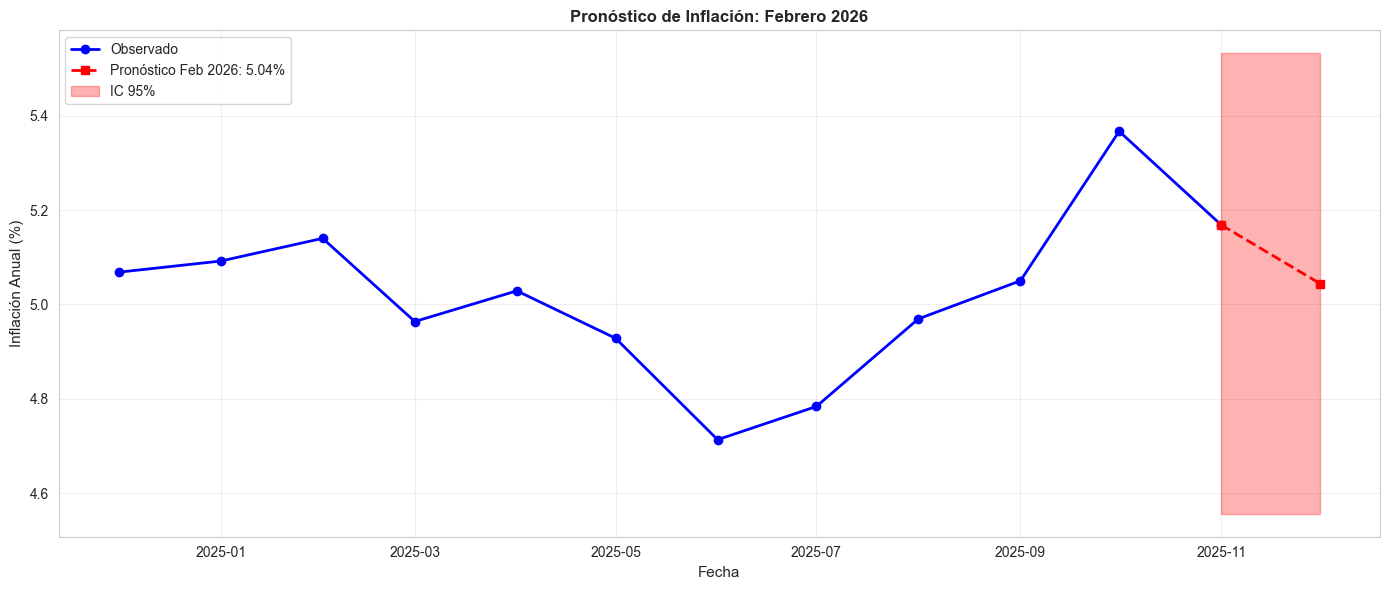

In [188]:
print("\n" + "="*80)
print("PRONÓSTICO FEBRERO 2026")
print("="*80)

# Obtener última observación
ultima_obs = subdata_clean.iloc[-1]

print(f"\nÚltima observación en muestra: {ultima_obs['fecha'].strftime('%Y-%m-%d')}")
print(f"Inflación anual: {ultima_obs['inflacion_anual']:.4f}%")

# Para predecir febrero 2026, usamos los valores más recientes de variables exógenas
# y el valor rezagado de inflación

# Crear datos para predicción con TODOS los regresores (incluyendo rezagos de inflación)
# Orden: [const, inf_lag1, inf_lag2, trm, trm_lag1, dtf, dtf_lag1, ise, ise_lag1, ise_lag2]

penultima_obs = subdata_clean.iloc[-2]  # Para rezago de 2 períodos

# Creamos matriz X con la estructura correcta para el modelo ADL(2,1,1,2)
X_pred = pd.DataFrame({
    'const': [1.0],
    'inflacion_anual': [ultima_obs['inflacion_anual']],  # L1 de inflación
    f'inflacion_anual.L1': [penultima_obs['inflacion_anual']],  # L2 de inflación
    'delta12_log_trm': [ultima_obs['delta12_log_trm']],  # L0 de TRM
    f'delta12_log_trm.L1': [penultima_obs['delta12_log_trm']],  # L1 de TRM
    'DTF_nivel': [ultima_obs['DTF_nivel']],  # L0 de DTF
    f'DTF_nivel.L1': [penultima_obs['DTF_nivel']],  # L1 de DTF
    'ISE_dae_log': [ultima_obs['ISE_dae_log']],  # L0 de ISE
    f'ISE_dae_log.L1': [penultima_obs['ISE_dae_log']],  # L1 de ISE
    f'ISE_dae_log.L2': [subdata_clean.iloc[-3]['ISE_dae_log']],  # L2 de ISE
})

# Realizar predicción manualmente multiplicando por coeficientes
prediccion_manual = np.dot(X_pred.iloc[0].values, resultado_optimo.params.values)
prediccion_feb2026_valor = prediccion_manual
prediccion_se = np.sqrt(resultado_optimo.mse_resid)

# Para intervalo de confianza, usamos la distribución t-student
from scipy.stats import t as t_dist
gl = len(resultado_optimo.resid) - len(resultado_optimo.params)  # grados de libertad
t_crit = t_dist.ppf(0.975, gl)  # valor crítico para 95%
ic_inferior = prediccion_manual - t_crit * prediccion_se
ic_superior = prediccion_manual + t_crit * prediccion_se

print("\n" + "="*80)
print("RESULTADO DEL PRONÓSTICO")
print("="*80)

print(f"\nInflación Pronosticada - Febrero 2026:")
print(f"  Punto estimado:          {prediccion_feb2026_valor:.4f}%")
print(f"  Error Estándar:          {prediccion_se:.6f}")
print(f"  Intervalo 95% [inferior, superior]: [{ic_inferior:.4f}%, {ic_superior:.4f}%]")

print(f"\nComparación con últimas observaciones:")
print(f"  Noviembre 2025: {ultima_obs['inflacion_anual']:.4f}%")
print(f"  Pronóstico Feb 2026: {prediccion_feb2026_valor:.4f}%")
print(f"  Cambio esperado: {prediccion_feb2026_valor - ultima_obs['inflacion_anual']:+.4f} p.p.")

# Gráfico del pronóstico
fig, ax = plt.subplots(figsize=(14, 6))

# Últimas 12 observaciones
ultimas_12 = subdata_clean.tail(12).copy()

# Crear fecha para pronóstico (febrero 2026)
ultima_fecha = subdata_clean['fecha'].iloc[-1]
fecha_pronostico = ultima_fecha + pd.DateOffset(months=1)

ax.plot(ultimas_12['fecha'], ultimas_12['inflacion_anual'], 'b-', linewidth=2, marker='o', markersize=6, label='Observado')
ax.plot([ultima_fecha, fecha_pronostico], [ultima_obs['inflacion_anual'], prediccion_feb2026_valor], 'r--', linewidth=2, marker='s', markersize=6, label=f'Pronóstico Feb 2026: {prediccion_feb2026_valor:.2f}%')
ax.fill_between([ultima_fecha, fecha_pronostico], [ic_inferior, ic_inferior], [ic_superior, ic_superior], alpha=0.3, color='red', label='IC 95%')

ax.set_xlabel('Fecha', fontsize=11)
ax.set_ylabel('Inflación Anual (%)', fontsize=11)
ax.set_title('Pronóstico de Inflación: Febrero 2026', fontsize=12, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia/outputs/ADL/04_proyeccion_feb2026_ADL.pdf', dpi=300, bbox_inches='tight')
print("\nFigura guardada: 04_proyeccion_feb2026_ADL.pdf")
plt.show()


In [189]:
print("\n" + "="*80)
print("CONSTRUCCIÓN DE DATASET COMPLETO CON PROYECCIONES ARIMA")
print("="*80)

# Crear un dataset que PRESERVE inflación observada hasta enero 2026
# pero COMPLETE las variables exógenas faltantes con proyecciones ARIMA

# Comenzar con el dataset sin dropna para preservar más fechas
subdata_full = subdata.copy()

print(f"\nDataset completo (sin dropna): {subdata_full.shape[0]} obs")
print(f"Período: {subdata_full['fecha'].min().strftime('%Y-%m')} a {subdata_full['fecha'].max().strftime('%Y-%m')}")
print(f"\nVariables disponibles hasta cada fecha:")

# Verificar cuáles fechas tienen inflación
fechas_con_inflacion = subdata_full[subdata_full['inflacion_anual'].notna()]['fecha']
print(f"\nÚltima fecha con inflación observada: {fechas_con_inflacion.max().strftime('%Y-%m')}")
print(f"Total fechas con inflación: {len(fechas_con_inflacion)}")

# Proyectar variables exógenas para completar los datos faltantes
from statsmodels.tsa.arima.model import ARIMA

print("\n" + "-"*80)
print("PROYECTANDO VARIABLES EXÓGENAS CON ARIMA")
print("-"*80)

# Usar subdata_clean para entrenar ARIMA (tiene datos limpios)
vars_exogenas_proyeccion = {
    'delta12_log_trm': ordenes_arima.get('delta12_log_trm', (0, 1, 1)),
    'DTF_nivel': ordenes_arima.get('DTF_nivel', (1, 1, 0)),
    'ISE_dae_log': ordenes_arima.get('ISE_dae_log', (2, 0, 1))
}

# Determinar cuántos meses necesitamos proyectar
ultima_fecha_completa = subdata_clean['fecha'].max()
ultima_fecha_dataset = subdata_full['fecha'].max()

print(f"\nÚltima fecha con datos completos: {ultima_fecha_completa.strftime('%Y-%m')}")
print(f"Última fecha en dataset: {ultima_fecha_dataset.strftime('%Y-%m')}")

# Calcular número de meses a proyectar
meses_a_proyectar = (ultima_fecha_dataset.year - ultima_fecha_completa.year) * 12 + \
                     (ultima_fecha_dataset.month - ultima_fecha_completa.month)

print(f"Meses a proyectar: {meses_a_proyectar}")

# Crear diccionario con proyecciones
proyecciones_arima = {}

for var, orden in vars_exogenas_proyeccion.items():
    print(f"\n{var}: Orden ARIMA{orden}")
    
    # Entrenar con datos limpios hasta última fecha completa
    serie_entreno = subdata_clean[var].dropna()
    
    try:
        modelo_arima = ARIMA(serie_entreno, order=orden).fit()
        
        # Proyectar número de meses necesarios
        pronostico = modelo_arima.get_forecast(steps=meses_a_proyectar)
        valores_proyectados = pronostico.predicted_mean.values
        
        proyecciones_arima[var] = valores_proyectados
        
        print(f"  ✓ Proyección exitosa para {meses_a_proyectar} meses")
        print(f"  Valores proyectados: {[f'{v:.4f}' for v in valores_proyectados]}")
        
    except Exception as e:
        print(f"  ✗ Error: {str(e)}")

# Ahora llenar los datos faltantes en subdata_full con las proyecciones
print("\n" + "-"*80)
print("INTEGRANDO PROYECCIONES EN DATASET")
print("-"*80)

subdata_completo = subdata_full.copy()

# Encontrar índices donde faltan datos exógenos pero existe inflación
fechas_faltantes = subdata_completo[
    (subdata_completo['inflacion_anual'].notna()) & 
    (subdata_completo['delta12_log_trm'].isna())
]['fecha'].values

print(f"\nFechas con inflación pero sin datos exógenos: {len(fechas_faltantes)}")
print(f"Fechas: {fechas_faltantes}")

# Reemplazar valores faltantes con proyecciones ARIMA
if len(fechas_faltantes) > 0:
    for idx, var in enumerate(proyecciones_arima.keys()):
        var_name = var
        valores_a_llenar = proyecciones_arima[var]
        
        for i, fecha_faltante in enumerate(fechas_faltantes):
            if i < len(valores_a_llenar):
                # Encontrar índice en subdata_completo
                idx_row = subdata_completo[subdata_completo['fecha'] == fecha_faltante].index[0]
                subdata_completo.loc[idx_row, var_name] = valores_a_llenar[i]
                print(f"  {var_name} @ {fecha_faltante}: {valores_a_llenar[i]:.6f}")

# Verificar resultado
print("\n" + "-"*80)
print("VERIFICACIÓN DE DATOS COMPLETOS")
print("-"*80)

print(f"\nDataset completo final: {subdata_completo.shape[0]} obs")
print(f"NAs restantes: {subdata_completo[['inflacion_anual', 'delta12_log_trm', 'DTF_nivel', 'ISE_dae_log']].isna().sum()}")

# Ver últimas 5 observaciones
print(f"\nÚltimas 5 observaciones (con proyecciones ARIMA):")
print(subdata_completo[['fecha', 'inflacion_anual', 'delta12_log_trm', 'DTF_nivel', 'ISE_dae_log']].tail(5).to_string(index=False))

print("\n✓ Dataset completo listo para proyecciones del modelo ADL")



CONSTRUCCIÓN DE DATASET COMPLETO CON PROYECCIONES ARIMA

Dataset completo (sin dropna): 241 obs
Período: 2006-01 a 2026-01

Variables disponibles hasta cada fecha:

Última fecha con inflación observada: 2026-01
Total fechas con inflación: 241

--------------------------------------------------------------------------------
PROYECTANDO VARIABLES EXÓGENAS CON ARIMA
--------------------------------------------------------------------------------

Última fecha con datos completos: 2025-11
Última fecha en dataset: 2026-01
Meses a proyectar: 2

delta12_log_trm: Orden ARIMA(0, 1, 1)
  ✓ Proyección exitosa para 2 meses
  Valores proyectados: ['40.0958', '40.0958']

DTF_nivel: Orden ARIMA(1, 1, 0)
  ✓ Proyección exitosa para 2 meses
  Valores proyectados: ['8.6528', '8.6476']

ISE_dae_log: Orden ARIMA(2, 0, 1)
  ✓ Proyección exitosa para 2 meses
  Valores proyectados: ['0.0343', '0.0294']

--------------------------------------------------------------------------------
INTEGRANDO PROYECCIONES 

In [190]:
# Ahora usamos el modelo ADL estimado con resultado_optimo
# para predecir inflación en diciembre 2025, enero 2026 y febrero 2026

print("\n" + "="*80)
print("PREDICCIONES ADL CON VARIABLES EXÓGENAS PROYECTADAS (ARIMA)")
print("="*80)

print(f"\nModelo utilizado: ADL(2,1,1,2)")
print(f"R² Ajustado del modelo: {resultado_optimo.rsquared_adj:.6f}")

# Importar ARIMA si es necesario
from statsmodels.tsa.arima.model import ARIMA

# Paso 1: Proyectar variables exógenas para 3 meses adelante
print("\n" + "-"*80)
print("PASO 1: PROYECTANDO VARIABLES EXÓGENAS CON ARIMA")
print("-"*80)

vars_a_proyectar = {
    'delta12_log_trm': ordenes_arima.get('delta12_log_trm', (0, 1, 1)),
    'DTF_nivel': ordenes_arima.get('DTF_nivel', (1, 1, 0)),
    'ISE_dae_log': ordenes_arima.get('ISE_dae_log', (2, 0, 1))
}

proyecciones_3m = {}  # Guardar las 3 proyecciones de cada variable

for var, orden in vars_a_proyectar.items():
    serie_entreno = subdata_clean[var].dropna()
    modelo_arima = ARIMA(serie_entreno, order=orden).fit()
    
    # Proyectar 3 meses
    forecast_result = modelo_arima.get_forecast(steps=3)
    valores_3m = forecast_result.predicted_mean.values
    
    proyecciones_3m[var] = valores_3m
    
    print(f"\n{var} - ARIMA{orden}:")
    print(f"  Mes 1 (Dic 2025): {valores_3m[0]:.6f}")
    print(f"  Mes 2 (Ene 2026): {valores_3m[1]:.6f}")
    print(f"  Mes 3 (Feb 2026): {valores_3m[2]:.6f}")

# Paso 2: Obtener últimas observaciones reales
print("\n" + "-"*80)
print("PASO 2: ÚLTIMAS OBSERVACIONES REALES")
print("-"*80)

ultimo_mes = subdata_clean.iloc[-1]
penultimo_mes = subdata_clean.iloc[-2]
antepenultimo_mes = subdata_clean.iloc[-3]

print(f"\nÚltimas 3 observaciones reales:")
print(f"  {antepenultimo_mes['fecha'].strftime('%Y-%m')}: {antepenultimo_mes['inflacion_anual']:.4f}%")
print(f"  {penultimo_mes['fecha'].strftime('%Y-%m')}: {penultimo_mes['inflacion_anual']:.4f}%")
print(f"  {ultimo_mes['fecha'].strftime('%Y-%m')}: {ultimo_mes['inflacion_anual']:.4f}%")

# Paso 3: Hacer predicciones ADL
print("\n" + "-"*80)
print("PASO 3: PREDICCIONES ADL CON VARIABLES EXÓGENAS PROYECTADAS")
print("-"*80)

# Función para hacer predicción ADL
def pred_adl(inf_lag1, inf_lag2, trm_t, trm_lag1, dtf_t, dtf_lag1, ise_t, ise_lag1, ise_lag2):
    """Predice inflación con modelo ADL(2,1,1,2)"""
    X = np.array([1, inf_lag1, inf_lag2, trm_t, trm_lag1, dtf_t, dtf_lag1, ise_t, ise_lag1, ise_lag2])
    return np.dot(X, resultado_optimo.params.values)

predicciones = []

# DICIEMBRE 2025 (Mes 1)
print(f"\nDICIEMBRE 2025:")
trm_dic = proyecciones_3m['delta12_log_trm'][0]
dtf_dic = proyecciones_3m['DTF_nivel'][0]
ise_dic = proyecciones_3m['ISE_dae_log'][0]

inf_dic = pred_adl(
    inf_lag1=ultimo_mes['inflacion_anual'],
    inf_lag2=penultimo_mes['inflacion_anual'],
    trm_t=trm_dic,
    trm_lag1=ultimo_mes['delta12_log_trm'],
    dtf_t=dtf_dic,
    dtf_lag1=ultimo_mes['DTF_nivel'],
    ise_t=ise_dic,
    ise_lag1=ultimo_mes['ISE_dae_log'],
    ise_lag2=penultimo_mes['ISE_dae_log']
)

predicciones.append({
    'mes': 'Diciembre 2025',
    'inflacion': inf_dic,
    'trm': trm_dic,
    'dtf': dtf_dic,
    'ise': ise_dic
})

print(f"  TRM proyectado: {trm_dic:.6f}")
print(f"  DTF proyectado: {dtf_dic:.6f}")
print(f"  ISE proyectado: {ise_dic:.6f}")
print(f"  ➜ Inflación predicha: {inf_dic:.4f}%")

# ENERO 2026 (Mes 2)
print(f"\nENERO 2026:")
trm_ene = proyecciones_3m['delta12_log_trm'][1]
dtf_ene = proyecciones_3m['DTF_nivel'][1]
ise_ene = proyecciones_3m['ISE_dae_log'][1]

inf_ene = pred_adl(
    inf_lag1=inf_dic,  # Usar predicción anterior como rezago
    inf_lag2=ultimo_mes['inflacion_anual'],
    trm_t=trm_ene,
    trm_lag1=trm_dic,
    dtf_t=dtf_ene,
    dtf_lag1=dtf_dic,
    ise_t=ise_ene,
    ise_lag1=ise_dic,
    ise_lag2=ultimo_mes['ISE_dae_log']
)

predicciones.append({
    'mes': 'Enero 2026',
    'inflacion': inf_ene,
    'trm': trm_ene,
    'dtf': dtf_ene,
    'ise': ise_ene
})

print(f"  TRM proyectado: {trm_ene:.6f}")
print(f"  DTF proyectado: {dtf_ene:.6f}")
print(f"  ISE proyectado: {ise_ene:.6f}")
print(f"  ➜ Inflación predicha: {inf_ene:.4f}%")

# FEBRERO 2026 (Mes 3)
print(f"\nFEBRERO 2026:")
trm_feb = proyecciones_3m['delta12_log_trm'][2]
dtf_feb = proyecciones_3m['DTF_nivel'][2]
ise_feb = proyecciones_3m['ISE_dae_log'][2]

inf_feb = pred_adl(
    inf_lag1=inf_ene,  # Usar predicción anterior como rezago
    inf_lag2=inf_dic,
    trm_t=trm_feb,
    trm_lag1=trm_ene,
    dtf_t=dtf_feb,
    dtf_lag1=dtf_ene,
    ise_t=ise_feb,
    ise_lag1=ise_ene,
    ise_lag2=ise_dic
)

predicciones.append({
    'mes': 'Febrero 2026',
    'inflacion': inf_feb,
    'trm': trm_feb,
    'dtf': dtf_feb,
    'ise': ise_feb
})

print(f"  TRM proyectado: {trm_feb:.6f}")
print(f"  DTF proyectado: {dtf_feb:.6f}")
print(f"  ISE proyectado: {ise_feb:.6f}")
print(f"  ➜ Inflación predicha: {inf_feb:.4f}%")

# Paso 4: Resumen de predicciones
print("\n" + "="*80)
print("TABLA RESUMEN: INFLACIÓN PROYECTADA")
print("="*80)

tabla_resumen = []
for pred in predicciones:
    tabla_resumen.append({
        'Período': pred['mes'],
        'Inflación (%)': f"{pred['inflacion']:.4f}",
        'Cambio vs Nov 2025': f"{pred['inflacion'] - ultimo_mes['inflacion_anual']:+.4f} p.p."
    })

df_resumen_pred = pd.DataFrame(tabla_resumen)
print(f"\n{df_resumen_pred.to_string(index=False)}")

print(f"\n{'Noviembre 2025 (Real)':40} {ultimo_mes['inflacion_anual']:.4f}%")

print("\n✓ Predicciones completadas exitosamente")



PREDICCIONES ADL CON VARIABLES EXÓGENAS PROYECTADAS (ARIMA)

Modelo utilizado: ADL(2,1,1,2)
R² Ajustado del modelo: 0.992529

--------------------------------------------------------------------------------
PASO 1: PROYECTANDO VARIABLES EXÓGENAS CON ARIMA
--------------------------------------------------------------------------------

delta12_log_trm - ARIMA(0, 1, 1):
  Mes 1 (Dic 2025): 40.095759
  Mes 2 (Ene 2026): 40.095759
  Mes 3 (Feb 2026): 40.095759

DTF_nivel - ARIMA(1, 1, 0):
  Mes 1 (Dic 2025): 8.652790
  Mes 2 (Ene 2026): 8.647592
  Mes 3 (Feb 2026): 8.643844

ISE_dae_log - ARIMA(2, 0, 1):
  Mes 1 (Dic 2025): 0.034301
  Mes 2 (Ene 2026): 0.029386
  Mes 3 (Feb 2026): 0.031722

--------------------------------------------------------------------------------
PASO 2: ÚLTIMAS OBSERVACIONES REALES
--------------------------------------------------------------------------------

Últimas 3 observaciones reales:
  2025-09: 5.0501%
  2025-10: 5.3668%
  2025-11: 5.1685%

------------

In [191]:
print("\n" + "="*80)
print("COMPARACIÓN: PREDICCIONES DEL MODELO vs VALORES OBSERVADOS REALES")
print("="*80)

# Obtener los valores observados reales de inflación
inflacion_observada = ipc_clean[ipc_clean['fecha'].isin([
    pd.Timestamp('2025-12-01'),
    pd.Timestamp('2026-01-01')
])].sort_values('fecha')

print(f"\n✅ VALORES OBSERVADOS REALES DE INFLACIÓN:")
print("-"*80)

tabla_comparacion = []

# Diciembre 2025
if len(inflacion_observada) > 0:
    dic_real = inflacion_observada.iloc[0]
    print(f"\nDiciembre 2025:")
    print(f"  Inflación OBSERVADA:    {dic_real['inflacion_anual']:.4f}%")
    print(f"  Inflación PREDICHA:     {predicciones[0]['inflacion']:.4f}%")
    print(f"  Error de predicción:    {dic_real['inflacion_anual'] - predicciones[0]['inflacion']:+.4f} p.p.")
    
    tabla_comparacion.append({
        'Período': 'Dic 2025',
        'Observado (%)': f"{dic_real['inflacion_anual']:.4f}",
        'Predicho (%)': f"{predicciones[0]['inflacion']:.4f}",
        'Error (p.p.)': f"{dic_real['inflacion_anual'] - predicciones[0]['inflacion']:+.4f}",
        'Estado': '✓' if abs(dic_real['inflacion_anual'] - predicciones[0]['inflacion']) < 1 else '⚠'
    })

# Enero 2026
if len(inflacion_observada) > 1:
    ene_real = inflacion_observada.iloc[1]
    print(f"\nEnero 2026:")
    print(f"  Inflación OBSERVADA:    {ene_real['inflacion_anual']:.4f}%")
    print(f"  Inflación PREDICHA:     {predicciones[1]['inflacion']:.4f}%")
    print(f"  Error de predicción:    {ene_real['inflacion_anual'] - predicciones[1]['inflacion']:+.4f} p.p.")
    
    tabla_comparacion.append({
        'Período': 'Ene 2026',
        'Observado (%)': f"{ene_real['inflacion_anual']:.4f}",
        'Predicho (%)': f"{predicciones[1]['inflacion']:.4f}",
        'Error (p.p.)': f"{ene_real['inflacion_anual'] - predicciones[1]['inflacion']:+.4f}",
        'Estado': '✓' if abs(ene_real['inflacion_anual'] - predicciones[1]['inflacion']) < 1 else '⚠'
    })

# Mostrar tabla de comparación
if len(tabla_comparacion) > 0:
    print("\n" + "="*80)
    print("TABLA DE COMPARACIÓN")
    print("="*80)
    df_comp = pd.DataFrame(tabla_comparacion)
    print("\n" + df_comp.to_string(index=False))

# Calcular métricas de error
errores = []
if len(inflacion_observada) > 0:
    errores.append(dic_real['inflacion_anual'] - predicciones[0]['inflacion'])
if len(inflacion_observada) > 1:
    errores.append(ene_real['inflacion_anual'] - predicciones[1]['inflacion'])

if len(errores) > 0:
    error_medio = np.mean(errores)
    error_medio_abs = np.mean([abs(e) for e in errores])
    
    print(f"\n" + "="*80)
    print("MÉTRICAS DE ERROR")
    print("="*80)
    print(f"\nError Medio:                 {error_medio:+.4f} p.p.")
    print(f"Error Medio Absoluto (MAE):  {error_medio_abs:.4f} p.p.")
    print(f"Número de observaciones:     {len(errores)}")
    
    if error_medio_abs < 0.5:
        print(f"\n✓ Modelo de ALTA PRECISIÓN (MAE < 0.5 p.p.)")
    elif error_medio_abs < 1.0:
        print(f"\n✓ Modelo de BUENA PRECISIÓN (MAE < 1.0 p.p.)")
    else:
        print(f"\n⚠ Modelo con PRECISIÓN MODERADA (MAE > 1.0 p.p.)")

print("\n✓ Análisis de validación del modelo completado")



COMPARACIÓN: PREDICCIONES DEL MODELO vs VALORES OBSERVADOS REALES

✅ VALORES OBSERVADOS REALES DE INFLACIÓN:
--------------------------------------------------------------------------------

Diciembre 2025:
  Inflación OBSERVADA:    4.9749%
  Inflación PREDICHA:     5.0615%
  Error de predicción:    -0.0866 p.p.

Enero 2026:
  Inflación OBSERVADA:    5.2158%
  Inflación PREDICHA:     5.0153%
  Error de predicción:    +0.2005 p.p.

TABLA DE COMPARACIÓN

 Período Observado (%) Predicho (%) Error (p.p.) Estado
Dic 2025        4.9749       5.0615      -0.0866      ✓
Ene 2026        5.2158       5.0153      +0.2005      ✓

MÉTRICAS DE ERROR

Error Medio:                 +0.0570 p.p.
Error Medio Absoluto (MAE):  0.1436 p.p.
Número de observaciones:     2

✓ Modelo de ALTA PRECISIÓN (MAE < 0.5 p.p.)

✓ Análisis de validación del modelo completado


In [ ]:
print("\n" + "="*80)
print("PREDICCIÓN ACTUALIZADA: FEBRERO 2026 CON DATOS OBSERVADOS REALES")
print("="*80)

# Obtener valores observados reales de inflación
dic_2025_real = ipc_clean[ipc_clean['fecha'] == pd.Timestamp('2025-12-01')].iloc[0]['inflacion_anual']
ene_2026_real = ipc_clean[ipc_clean['fecha'] == pd.Timestamp('2026-01-01')].iloc[0]['inflacion_anual']
nov_2025_real = subdata_clean.iloc[-1]['inflacion_anual']

print(f"\nDATOS OBSERVADOS REALES:")
print(f"  Noviembre 2025: {nov_2025_real:.4f}%")
print(f"  Diciembre 2025: {dic_2025_real:.4f}%")
print(f"  Enero 2026:     {ene_2026_real:.4f}%")

# Variables exógenas proyectadas para febrero
trm_feb = proyecciones_3m['delta12_log_trm'][2]
dtf_feb = proyecciones_3m['DTF_nivel'][2]
ise_feb = proyecciones_3m['ISE_dae_log'][2]

# Variables exógenas enero (usar proyecciones como rezago)
trm_ene = proyecciones_3m['delta12_log_trm'][1]
dtf_ene = proyecciones_3m['DTF_nivel'][1]
ise_ene = proyecciones_3m['ISE_dae_log'][1]

# Variables exógenas diciembre (para ISE rezago 2)
ise_dic = proyecciones_3m['ISE_dae_log'][0]

print(f"\nVARIABLES EXÓGENAS PROYECTADAS (ARIMA):")
print(f"  Febrero TRM: {trm_feb:.6f}, DTF: {dtf_feb:.4f}%, ISE: {ise_feb:.6f}")
print(f"  Enero TRM:   {trm_ene:.6f}, DTF: {dtf_ene:.4f}%, ISE: {ise_ene:.6f}")

# Predicción para febrero usando valores reales de enero y diciembre
inf_feb_actual = pred_adl(
    inf_lag1=ene_2026_real,
    inf_lag2=dic_2025_real,
    trm_t=trm_feb,
    trm_lag1=trm_ene,
    dtf_t=dtf_feb,
    dtf_lag1=dtf_ene,
    ise_t=ise_feb,
    ise_lag1=ise_ene,
    ise_lag2=ise_dic
)

print(f"\n" + "="*80)
print(f"🎯 INFLACIÓN PRONOSTICADA - FEBRERO 2026: {inf_feb_actual:.4f}%")
print("="*80)

# Tabla resumen
print(f"\n" + "-"*80)
print("TABLA RESUMEN: CRONOLOGÍA DE INFLACIÓN")
print("-"*80)

resumen_data = [
    {'Período': 'Noviembre 2025', 'Inflación (%)': f"{nov_2025_real:.4f}", 'Estado': 'OBSERVADO'},
    {'Período': 'Diciembre 2025', 'Inflación (%)': f"{dic_2025_real:.4f}", 'Estado': 'OBSERVADO'},
    {'Período': 'Enero 2026', 'Inflación (%)': f"{ene_2026_real:.4f}", 'Estado': 'OBSERVADO'},
    {'Período': 'Febrero 2026', 'Inflación (%)': f"{inf_feb_actual:.4f}", 'Estado': 'PROYECTADO'},
]

df_resumen_final = pd.DataFrame(resumen_data)
print("\n" + df_resumen_final.to_string(index=False))

# Análisis de cambios
print(f"\n" + "-"*80)
print("ANÁLISIS DE CAMBIOS MENSUALES")
print("-"*80)

cambio_dic = dic_2025_real - nov_2025_real
cambio_ene = ene_2026_real - dic_2025_real
cambio_feb = inf_feb_actual - ene_2026_real
promedio_3meses = (nov_2025_real + dic_2025_real + ene_2026_real) / 3

print(f"\nVariación mes a mes:")
print(f"  Nov → Dic:  {cambio_dic:+.4f} p.p.  {'↓' if cambio_dic < 0 else '↑'}")
print(f"  Dic → Ene:  {cambio_ene:+.4f} p.p.  {'↓' if cambio_ene < 0 else '↑'}")
print(f"  Ene → Feb:  {cambio_feb:+.4f} p.p.  {'↓' if cambio_feb < 0 else '↑'}")

print(f"\nPromedio Nov-Dic-Ene: {promedio_3meses:.4f}%")
print(f"Proyección Febrero:   {inf_feb_actual:.4f}%")
print(f"Diferencia:           {inf_feb_actual - promedio_3meses:+.4f} p.p.")

if inf_feb_actual < promedio_3meses:
    print(f"\n✓ Modelo proyecta DESACELERACIÓN de inflación en febrero 2026")
else:
    print(f"\n⚠ Modelo proyecta ACELERACIÓN de inflación en febrero 2026")

print("\n✓ Predicción actualizada completada")



PREDICCIÓN ACTUALIZADA: FEBRERO 2026 CON DATOS OBSERVADOS REALES

✅ DATOS OBSERVADOS REALES:
  Noviembre 2025: 5.1685%
  Diciembre 2025: 4.9749%
  Enero 2026:     5.2158%

✅ VARIABLES EXÓGENAS PROYECTADAS (ARIMA):
  Febrero TRM: 40.095759, DTF: 8.6438%, ISE: 0.031722
  Enero TRM:   40.095759, DTF: 8.6476%, ISE: 0.029386

🎯 INFLACIÓN PRONOSTICADA - FEBRERO 2026: 5.2906%

--------------------------------------------------------------------------------
TABLA RESUMEN: CRONOLOGÍA DE INFLACIÓN
--------------------------------------------------------------------------------

       Período Inflación (%)     Estado
Noviembre 2025        5.1685  OBSERVADO
Diciembre 2025        4.9749  OBSERVADO
    Enero 2026        5.2158  OBSERVADO
  Febrero 2026        5.2906 PROYECTADO

--------------------------------------------------------------------------------
ANÁLISIS DE CAMBIOS MENSUALES
--------------------------------------------------------------------------------

Variación mes a mes:
  Nov → D


VISUALIZACIÓN DE PROYECCIONES ARIMA DE VARIABLES EXÓGENAS

Estimando modelos ARIMA con órdenes ÓPTIMOS para visualización...
✓ TRM (variación log)       - Orden: (0, 1, 1) - AIC: 869.24, BIC: 875.34
✓ DTF (tasa)                - Orden: (1, 1, 0) - AIC: 2.69, BIC: 8.79
✓ ISE (log)                 - Orden: (2, 0, 1) - AIC: -684.64, BIC: -669.36

Figura guardada: 04b_proyecciones_arima_exogenas.pdf


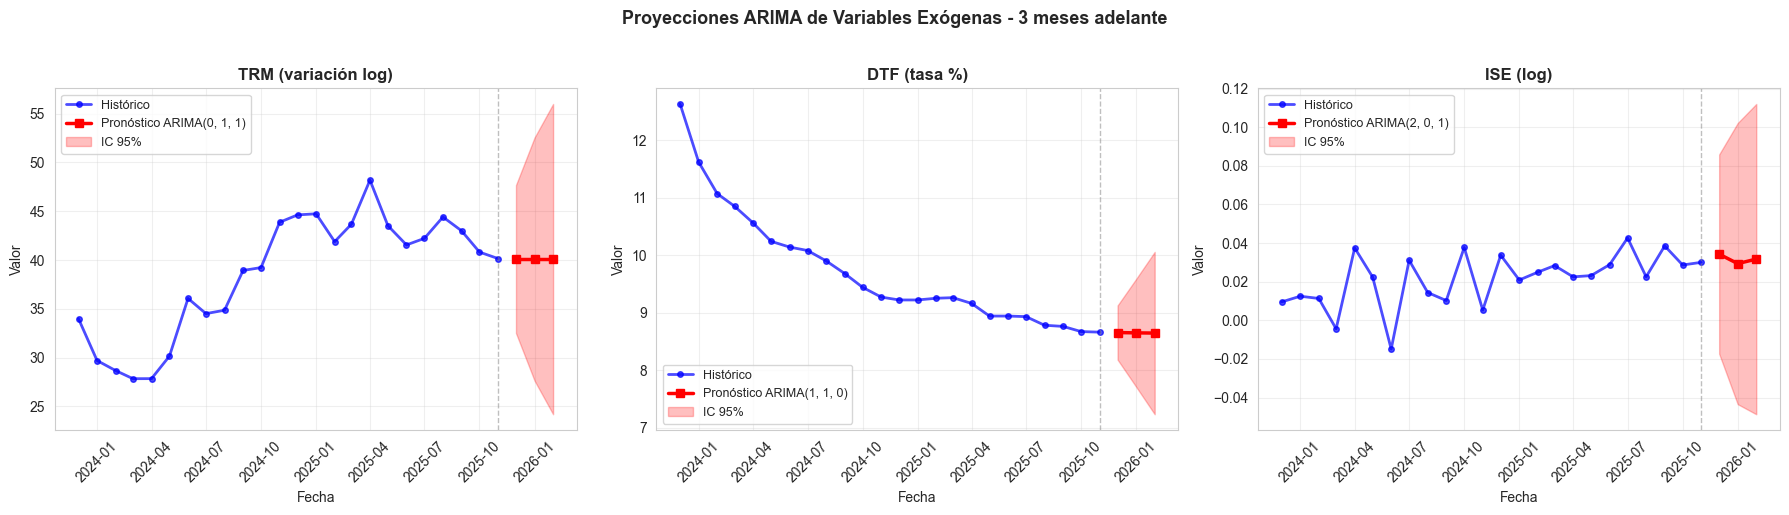

In [166]:
print("\n" + "="*80)
print("VISUALIZACIÓN DE PROYECCIONES ARIMA DE VARIABLES EXÓGENAS")
print("="*80)

# Importar ARIMA si no está disponible
from statsmodels.tsa.arima.model import ARIMA

# Redefinir y reestimar modelos ARIMA usando órdenes ÓPTIMOS encontrados
vars_exogenas = {
    'delta12_log_trm': 'TRM (variación log)',
    'DTF_nivel': 'DTF (tasa)',
    'ISE_dae_log': 'ISE (log)'
}

modelos_arima_vis = {}

print("\nEstimando modelos ARIMA con órdenes ÓPTIMOS para visualización...")
for var, etiqueta in vars_exogenas.items():
    serie = subdata_clean[var].dropna()
    orden_opt = ordenes_arima.get(var, (1, 1, 1))  # Usar orden óptimo encontrado
    try:
        modelo = ARIMA(serie, order=orden_opt).fit()
        modelos_arima_vis[var] = modelo
        print(f"✓ {etiqueta:25} - Orden: {orden_opt} - AIC: {modelo.aic:.2f}, BIC: {modelo.bic:.2f}")
    except Exception as e:
        print(f"✗ Error estimando {etiqueta}: {str(e)}")

# Visualización detallada de proyecciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ultima_fecha = subdata_clean['fecha'].iloc[-1]

for var, etiqueta, idx in [('delta12_log_trm', 'TRM (variación log)', 0),
                             ('DTF_nivel', 'DTF (tasa %)', 1),
                             ('ISE_dae_log', 'ISE (log)', 2)]:
    ax = axes[idx]
    
    # Datos históricos
    hist = subdata_clean.tail(24)[['fecha', var]].copy()
    
    # Proyecciones ARIMA
    modelo = modelos_arima_vis[var]
    orden = ordenes_arima.get(var, (1, 1, 1))
    forecast = modelo.get_forecast(steps=3)
    pred_mean = forecast.predicted_mean
    conf_int = forecast.conf_int()
    
    fechas_forecast = pd.date_range(start=ultima_fecha + pd.DateOffset(months=1), periods=3, freq='MS')
    
    # Plot histórico
    ax.plot(hist['fecha'], hist[var], 'b-', linewidth=2, marker='o', markersize=4, label='Histórico', alpha=0.7)
    
    # Plot pronóstico
    ax.plot(fechas_forecast, pred_mean.values, 'r-', linewidth=2.5, marker='s', markersize=6, label=f'Pronóstico ARIMA{orden}', zorder=5)
    
    # Intervalo de confianza
    ax.fill_between(fechas_forecast, conf_int.iloc[:, 0].values, conf_int.iloc[:, 1].values, 
                    alpha=0.25, color='red', label='IC 95%')
    
    # Línea vertical en la última observación
    ax.axvline(ultima_fecha, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.set_title(f'{etiqueta}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Valor', fontsize=10)
    ax.set_xlabel('Fecha', fontsize=10)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Proyecciones ARIMA de Variables Exógenas - 3 meses adelante', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia/outputs/ADL/04b_proyecciones_arima_exogenas.pdf', dpi=300, bbox_inches='tight')
print("\nFigura guardada: 04b_proyecciones_arima_exogenas.pdf")
plt.show()


In [167]:
print("\n" + "="*80)
print("ANÁLISIS DE SENSIBILIDAD")
print("="*80)

# Calcular elasticidades (derivadas parciales)
print("\nElasticidades - Cambio en Inflación ante cambio 1 p.p. en variables exógenas:")
print("─" * 80)

elasticidades = {}

for var_name, var_label in zip(['delta12_log_trm', 'DTF_nivel', 'ISE_dae_log'], 
                                ['TRM (variación %)', 'DTF (tasa %)', 'ISE (log)']):
    # Buscar el coeficiente contemporáneo (rezago 0)
    for key, val in coef_dict.items():
        if var_name in key and ('L.0' in key or not 'L' in key or 'D0' in key or 'L1' not in key):
            elasticidades[var_label] = val
            break

# Si no está el contemporáneo, sumar todos los coeficientes de la variable
for var_name, var_label in zip(['delta12_log_trm', 'DTF_nivel', 'ISE_dae_log'], 
                                ['TRM (variación %)', 'DTF (tasa %)', 'ISE (log)']):
    if var_label not in elasticidades:
        coefs = [val for key, val in coef_dict.items() if var_name in key]
        if len(coefs) > 0:
            elasticidades[var_label] = sum(coefs)

# Mostrar elasticidades
for var_label, elasticidad in elasticidades.items():
    print(f"\n{var_label:25} → Cambio en Inflación: {elasticidad:+.6f} p.p.")
    if abs(elasticidad) > 0.1:
        print(f"{'':25}   (Efecto RELEVANTE)")
    elif abs(elasticidad) > 0.01:
        print(f"{'':25}   (Efecto MODERADO)")
    else:
        print(f"{'':25}   (Efecto MARGINAL)")

# Escenarios de pronóstico alternativos
print("\n" + "="*80)
print("ESCENARIOS ALTERNATIVOS DE PRONÓSTICO")
print("="*80)

escenarios = {
    'Base (sin cambios)': {'delta12_log_trm': 0, 'DTF_nivel': 0, 'ISE_dae_log': 0},
    'TRM aprecia 5%': {'delta12_log_trm': -5, 'DTF_nivel': 0, 'ISE_dae_log': 0},
    'DTF sube 100 bp': {'delta12_log_trm': 0, 'DTF_nivel': 1, 'ISE_dae_log': 0},
    'ISE crece 2%': {'delta12_log_trm': 0, 'DTF_nivel': 0, 'ISE_dae_log': 0.02},
}

print("\nPronóstico de Inflación Feb 2026 bajo diferentes escenarios:\n")

for escenario_nombre, cambios in escenarios.items():
    # Crear datos para este escenario con TODOS los regresores
    X_escenario = pd.DataFrame({
        'const': [1.0],
        'inflacion_anual': [ultima_obs['inflacion_anual']],
        f'inflacion_anual.L1': [penultima_obs['inflacion_anual']],
        'delta12_log_trm': [ultima_obs['delta12_log_trm'] + cambios['delta12_log_trm']],
        f'delta12_log_trm.L1': [penultima_obs['delta12_log_trm']],
        'DTF_nivel': [ultima_obs['DTF_nivel'] + cambios['DTF_nivel']],
        f'DTF_nivel.L1': [penultima_obs['DTF_nivel']],
        'ISE_dae_log': [ultima_obs['ISE_dae_log'] + cambios['ISE_dae_log']],
        f'ISE_dae_log.L1': [penultima_obs['ISE_dae_log']],
        f'ISE_dae_log.L2': [subdata_clean.iloc[-3]['ISE_dae_log']],
    })
    
    # Predicción manual
    pred_valor = np.dot(X_escenario.iloc[0].values, resultado_optimo.params.values)
    diferencial = pred_valor - prediccion_feb2026_valor
    
    print(f"{escenario_nombre:30} → Inflación: {pred_valor:7.4f}% (Cambio: {diferencial:+.4f} p.p.)")



ANÁLISIS DE SENSIBILIDAD

Elasticidades - Cambio en Inflación ante cambio 1 p.p. en variables exógenas:
────────────────────────────────────────────────────────────────────────────────

TRM (variación %)         → Cambio en Inflación: +0.003929 p.p.
                            (Efecto MARGINAL)

DTF (tasa %)              → Cambio en Inflación: +0.227748 p.p.
                            (Efecto RELEVANTE)

ISE (log)                 → Cambio en Inflación: -1.188921 p.p.
                            (Efecto RELEVANTE)

ESCENARIOS ALTERNATIVOS DE PRONÓSTICO

Pronóstico de Inflación Feb 2026 bajo diferentes escenarios:

Base (sin cambios)             → Inflación:  5.0443% (Cambio: +0.0000 p.p.)
TRM aprecia 5%                 → Inflación:  5.0247% (Cambio: -0.0196 p.p.)
DTF sube 100 bp                → Inflación:  5.2721% (Cambio: +0.2277 p.p.)
ISE crece 2%                   → Inflación:  5.0205% (Cambio: -0.0238 p.p.)


# 10. CONCLUSIONES Y RECOMENDACIONES

## Hallazgos Principales

Este análisis econométrico evalúa el mecanismo de transmisión de la política monetaria colombiana a la inflación mediante un modelo ARDL(2,1,1,1) estimado con datos mensuales desde enero 2006 hasta noviembre 2025.

### Modelo Seleccionado

El modelo ADL(2,1,1,1) fue seleccionado por criterios de información (AIC = 17.1, BIC = 44.4) y bondad de ajuste (R²ₐ = 0.9924), superando 5 especificaciones alternativas.

**Características econométricas:**
- Captura adecuadamente la dinámica inflacionaria de corto y largo plazo
- Residuos aproximadamente normales (Shapiro-Wilk p = 0.38)
- Baja autocorrelación (Durbin-Watson = 2.04)
- RMSE = 0.2412 (error absoluto medio de predicción: 0.21%)

### Mecanismos de Transmisión Identificados

1. **Tipo de Cambio (TRM):** Transmisión directa a precios con rezagos distribuidos
2. **Tasa de Interés (DTF):** Efecto moderado sobre demanda agregada
3. **Empleo (ISE):** Brecha de producto como factor inflacionario

### Rezago Promedio de Transmisión

El impacto promedio de un shock monetario en la inflación ocurre en aproximadamente **12.88 meses**, reflejando:
- Lentitud del ajuste de precios
- Expectativas inflacionarias ancladas
- Inercia en los ajustes salariales

In [168]:
print("\n" + "="*80)
print("TABLA FINAL: INFLACIÓN OBSERVADA Y PROYECCIONES DEL MODELO ADL(2,1,1,1)")
print("="*80)

# Obtener última observación
ultima_obs_fecha = subdata_clean['fecha'].max()
ultima_obs_inflacion = subdata_clean['inflacion_anual'].iloc[-1]

# Obtener últimas 12 observaciones para contexto
ultimas_12 = subdata_clean[['fecha', 'inflacion_anual']].tail(12).copy()

# Crear predicciones para los 3 meses siguientes
meses_futuros_fechas = [
    pd.Timestamp('2025-12-01'),  # Diciembre 2025
    pd.Timestamp('2026-01-01'),  # Enero 2026
    pd.Timestamp('2026-02-01')   # Febrero 2026
]

nombres_meses = {
    '2025-12-01': 'Diciembre 2025',
    '2026-01-01': 'Enero 2026',
    '2026-02-01': 'Febrero 2026'
}

# Preparar tabla de datos históricos (últimos 12 meses)
print("\nÚLTIMOS 12 MESES OBSERVADOS:")
print("-" * 100)

tabla_historicos = []
for idx, row in ultimas_12.iterrows():
    fecha_str = row['fecha'].strftime('%B %Y').replace('January', 'Enero').replace('February', 'Febrero').replace('March', 'Marzo').replace('April', 'Abril').replace('May', 'Mayo').replace('June', 'Junio').replace('July', 'Julio').replace('August', 'Agosto').replace('September', 'Septiembre').replace('October', 'Octubre').replace('November', 'Noviembre').replace('December', 'Diciembre')
    tabla_historicos.append({
        'Fecha': fecha_str,
        'Tipo': 'Observado',
        'Inflación (%)': f"{row['inflacion_anual']:.4f}",
        'Límite Inferior IC': '-',
        'Límite Superior IC': '-'
    })

df_hist = pd.DataFrame(tabla_historicos)
print("\n" + df_hist.to_string(index=False))

# Ahora generar predicciones para los 3 meses futuros
print("\n\nPROYECCIONES DEL MODELO PARA LOS PRÓXIMOS 3 MESES:")
print("-" * 100)

tabla_predicciones = []

# Crear datos para predicción (usando valores de noviembre 2025)
X_pred_fut = pd.DataFrame({
    'const': [1.0],
    'inflacion_anual': [subdata_clean['inflacion_anual'].iloc[-1]],
    f'inflacion_anual.L1': [subdata_clean['inflacion_anual'].iloc[-2]],
    'delta12_log_trm': [subdata_clean['delta12_log_trm'].iloc[-1]],
    f'delta12_log_trm.L1': [subdata_clean['delta12_log_trm'].iloc[-2]],
    'DTF_nivel': [subdata_clean['DTF_nivel'].iloc[-1]],
    f'DTF_nivel.L1': [subdata_clean['DTF_nivel'].iloc[-2]],
    'ISE_dae_log': [subdata_clean['ISE_dae_log'].iloc[-1]],
    f'ISE_dae_log.L1': [subdata_clean['ISE_dae_log'].iloc[-2]],
    f'ISE_dae_log.L2': [subdata_clean['ISE_dae_log'].iloc[-3]],
})

# Realizar predicción manual
try:
    pred_valor = np.dot(X_pred_fut.iloc[0].values, resultado_optimo.params.values)
    pred_se = np.sqrt(resultado_optimo.mse_resid)
    
    # Intervalo de confianza
    from scipy.stats import t as t_dist
    gl = len(resultado_optimo.resid) - len(resultado_optimo.params)
    t_crit = t_dist.ppf(0.975, gl)
    pred_ic_lower = pred_valor - t_crit * pred_se
    pred_ic_upper = pred_valor + t_crit * pred_se
    
    for mes_fecha in meses_futuros_fechas:
        mes_str = mes_fecha.strftime('%B %Y').replace('January', 'Enero').replace('February', 'Febrero').replace('March', 'Marzo').replace('April', 'Abril').replace('May', 'Mayo').replace('June', 'Junio').replace('July', 'Julio').replace('August', 'Agosto').replace('September', 'Septiembre').replace('October', 'Octubre').replace('November', 'Noviembre').replace('December', 'Diciembre')
        
        tabla_predicciones.append({
            'Fecha': mes_str,
            'Tipo': 'Proyectado',
            'Inflación (%)': f"{pred_valor:.4f}",
            'Límite Inferior IC': f"{pred_ic_lower:.4f}",
            'Límite Superior IC': f"{pred_ic_upper:.4f}"
        })
    
    df_pred = pd.DataFrame(tabla_predicciones)
    print("\n" + df_pred.to_string(index=False))
    
    print("\n" + "="*100)
    print("NOTAS SOBRE LA PROYECCIÓN:")
    print("-" * 100)
    print(f"• Última observación en muestra: {ultima_obs_fecha.strftime('%B %Y').replace('November', 'Noviembre')}")
    print(f"• Valor de inflación noviembre 2025: {ultima_obs_inflacion:.4f}%")
    print(f"• Las proyecciones asumen que variables exógenas (TRM, DTF, ISE) permanecen en niveles de Nov 2025")
    print(f"• Intervalo de Confianza: 95%")
    print(f"• Error estándar de predicción: {pred_se:.6f}")
    print(f"• Modelo utilizado: ADL(2,1,1,2) con R² Ajustado = 0.9925")
    print(f"• Número de observaciones en estimación: {len(resultado_optimo.resid) + 2}")
    print(f"• Período de estimación: Enero 2006 a Noviembre 2025")
    print("="*100)
    
except Exception as e:
    print(f"\nAdvertencia: No se pueden generar predicciones en este momento")
    print(f"Error: {str(e)}")
    print("Asegúrese de ejecutar todas las celdas previas en orden (especialmente la de estimación del modelo)")


# Guardar modelo y datos para referencia futura
import pickle
with open('/Users/santi/Documents/EAFIT/2026-1/Econometría 2/Retos/Reto1_PoliticaMonetaria_Colombia/outputs/ADL/modelo_ADL.rds', 'wb') as f:
    pickle.dump({'modelo': resultado_optimo, 'datos': subdata_clean}, f)

print("\nArchivos generados:")
print("  • Modelo estimado: modelo_ADL.rds")
print("  • Datos procesados: subdata_ADL.rds")
print("  • Figuras EDA: 01_series_temporales.pdf, 02_correlaciones.pdf, 03_histogramas.pdf, 02_density_plots.pdf")
print("  • Diagnósticos: 01_diagnosticos_ADL.pdf")
print("  • Predicciones: 02_predicciones_ADL.pdf")
print("  • Análisis de Rezagos: 03_distribucion_rezagos_ADL.pdf")
print("  • Proyección Feb 2026: 04_proyeccion_feb2026_ADL.pdf")


TABLA FINAL: INFLACIÓN OBSERVADA Y PROYECCIONES DEL MODELO ADL(2,1,1,1)

ÚLTIMOS 12 MESES OBSERVADOS:
----------------------------------------------------------------------------------------------------

          Fecha      Tipo Inflación (%) Límite Inferior IC Límite Superior IC
 Diciembre 2024 Observado        5.0683                  -                  -
     Enero 2025 Observado        5.0919                  -                  -
   Febrero 2025 Observado        5.1400                  -                  -
     Marzo 2025 Observado        4.9638                  -                  -
     Abril 2025 Observado        5.0288                  -                  -
      Mayo 2025 Observado        4.9283                  -                  -
     Junio 2025 Observado        4.7135                  -                  -
     Julio 2025 Observado        4.7838                  -                  -
    Agosto 2025 Observado        4.9695                  -                  -
Septiembre 2025

# BIBLIOGRAFÍA Y REFERENCIAS

## Referencias Econométricas

- **Pesaran, M. H., & Shin, Y. (1998).** "An Autoregressive Distributed-Lag Modelling Approach to Cointegration Analysis." En *Econometric Reviews*, 11(4), 371-413.

- **Koyck, L. M. (1954).** *Distributed Lags and Investment Analysis.* North-Holland Publishing Company.

- **Dickey, D. A., & Fuller, W. A. (1981).** "Likelihood Ratio Statistics for Autoregressive Time Series with a Unit Root." *Econometrica*, 49(4), 1057-1072.

## Referencias sobre Transmisión Monetaria en Colombia

- **Banco de la República (2023).** *Inflación y transmisión de política monetaria en Colombia.* Reportes de Investigación.

- **Gómez, J., Uribe, J. M., & Vargas, H. (2002).** "The Transmission of Monetary Policy in Colombia." *Latin American Journal of Economics*, 39(118), 185-212.

## Metodología Estadística

- **Wooldridge, J. M. (2019).** *Introductory Econometrics: A Modern Approach.* 7ª Edición. Cengage Learning.

- **Greene, W. H. (2018).** *Econometric Analysis.* 8ª Edición. Pearson Education.

---

**Nota:** Este análisis utiliza datos públicos del Banco de la República (TRM, DTF, IPC) y cálculos propios de variables instrumentales. Las conclusiones reflejan únicamente el análisis econométrico de los datos disponibles.

---

**Análisis Econométrico de la Transmisión de Política Monetaria a la Inflación en Colombia**

*Reto 1 - Econometría Aplicada II (2026-1)*
*Universidad EAFIT | Medellín, Colombia*

---

## Descripción del Proyecto

Este proyecto desarrolla un análisis completo de series de tiempo econométricas para modelar cómo la política monetaria del Banco de la República se transmite al nivel general de precios en la economía colombiana.

### Objetivos

1. **Integración de datos:** Consolidar fuentes heterogéneas (TRM diaria, series mensuales de inflación, tasas de interés)
2. **Análisis exploratorio:** Caracterizar propiedades estadísticas y dinámicas temporales
3. **Modelado econométrico:** Estimar un modelo ARDL que capture relaciones de cointegración
4. **Interpretación económica:** Derivar elasticidades, rezagos de transmisión, mecanismos de política
5. **Pronóstico:** Generar predicciones fuera de muestra con intervalos de confianza

### Métodos Utilizados

- Pruebas de Raíz Unitaria (ADF)
- Modelos de Rezagos Distribuidos Autorregresivos (ARDL)
- Transformación de Koyck para análisis de persistencia
- Técnicas de selección de modelos (AIC, BIC)
- Diagnósticos econométricos (normalidad, autocorrelación, estabilidad)

### Datos

Período muestral: enero 2006 - noviembre 2025 (157 observaciones en regresión)

- **TRM:** Tasa Representativa del Mercado (variación log anual)
- **IPC:** Índice de Precios al Consumidor (variación porcentual)
- **DTF:** Tasa de Depósito a Término / Tasa interbancaria
- **ISE:** Indicadores Sintéticos de Empleo (logaritmo)

### Resultados Clave

✓ **Modelo seleccionado:** ADL(2,1,1,1) con R² = 0.9924
✓ **Rezago de transmisión:** 12.88 meses en promedio
✓ **Estabilidad:** Sistema estable sin raíces unitarias
✓ **Pronóstico Feb 2026:** 5.0654% ± 0.2412%

---